In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
import numpy as np
from math import sin, cos, pi

from holoviews.plotting.bokeh.styles import font_size

In [85]:
#!pip install biopython

In [2]:
def read_mapping():
    paf_columns = [
    "Query name",             # Nombre de la secuencia de consulta
    "Query length",           # Longitud de la secuencia de consulta
    "Query start",            # Posición de inicio del alineamiento en la consulta
    "Query end",              # Posición de fin del alineamiento en la consulta
    "Strand",                 # Dirección del alineamiento (+ o -)
    "Target name",            # Nombre de la secuencia de referencia
    "Target length",          # Longitud de la secuencia de referencia
    "Target start",           # Posición de inicio del alineamiento en la referencia
    "Target end",             # Posición de fin del alineamiento en la referencia
    "Number of matching bases",   # Número de bases que coinciden exactamente
    "Alignment block length",     # Longitud total del bloque de alineamiento
    "Mapping quality",        # Puntaje de calidad del mapeo
    "NM",                     # Number of mismatches
    "ms",                     # Score of the second best chain
    "AS",                     # Alignment score
    "nn",                     # Number of ambiguous bases
    "tp",                     # Type of alignment
    "cm",                     # Count of minimizers on the chain
    "s1",                     # Chaining score
    "s2",                     # Chaining score of the second best chain
    "de",                     # Sequence divergence
    "zd",                     # Z-score of the highest scoring chain
    "rl",                     # Reference length covered
    "cg"                      # CIGAR string
]

    mapping = pd.read_csv('../genome_mapping/alignment.paf', sep='\t', header=None, names=paf_columns)
    return mapping

In [3]:
def process_mapping():
    mapping = read_mapping()
    mapping.head()
    #print(mapping['AS'])
    temp_query = []
    df_map = pd.DataFrame(columns=['Mapping quality', 'Number of matching bases', 'Query name', 'Target name', 'Target start', 'Target end', 'Query length', 'Target length'])
    # for i in range(len(mapping['Mapping quality'])):
    #     if(mapping['Mapping quality'][i]==60):
    #         q_coverage = (mapping['Number of matching bases'][i]*100)/mapping['Query length'][i]
    #         t_coverage = (mapping['Number of matching bases'][i]*100)/mapping['Target length'][i]
    #         if q_coverage > 80 and t_coverage > 60:
    #             temp_query.append( mapping['Query name'][i])
    #             print(mapping['Mapping quality'][i], mapping['Query name'][i], mapping['Target name'][i], mapping['Target start'][i], mapping['Target end'][i])
    count_t = 0
    for i in range(len(mapping['Mapping quality'])):
        if('NC' in mapping['Target name'][i]):
            if(mapping['Mapping quality'][i]>=60 and mapping['Number of matching bases'][i] >= 50000):
                q_coverage = (mapping['Number of matching bases'][i]*100)/mapping['Query length'][i]
                t_coverage = (mapping['Number of matching bases'][i]*100)/mapping['Target length'][i]
                if q_coverage > 80:
                    temp_query.append( mapping['Target name'][i])
                    #print(mapping['Number of matching bases'][i], mapping['Query name'][i], mapping['Target name'][i], mapping['Target start'][i], mapping['Target end'][i])
                    values = [
                        mapping['Mapping quality'][i],
                        mapping['Number of matching bases'][i],
                        mapping['Query name'][i],
                        mapping['Target name'][i],
                        mapping['Target start'][i],
                        mapping['Target end'][i],
                        mapping['Query length'][i],
                        mapping['Target length'][i]
                    ]
                    df_map.loc[len(df_map)] = values
                    count_t=count_t+1
            #print(mapping['Mapping quality'][i], mapping['Query name'][i], mapping['Target name'][i], mapping['Target start'][i], mapping['Target end'][i])
    #print(set(temp_query))
    df_map_sorted = df_map.sort_values(by=['Target name', 'Target start', 'Target end'])
    df_map_sorted = df_map_sorted.reset_index(drop=True)
    return df_map_sorted
    #print(set(temp_query))
    #query_in_mapping = list(set(mapping['Query name'].tolist()))
    #target_in_mapping = list(set(mapping['Target name'].tolist()))
    #print(query_in_mapping)
temp = process_mapping()
print(set(temp['Target name'].tolist()))
temp.head(50)

FileNotFoundError: [Errno 2] No such file or directory: '../genome_mapping/alignment.paf'

In [4]:
def read_annotation(file):
    column_names = [
    "Repeat_ID",
    "Divergence",
    "Deletion",
    "Insertion",
    "Sequence_Name",
    "Alignment_Start",
    "Alignment_End",
    "Element_Length",
    "Orientation",
    "Family_Name",
    "Class",
    "Base_Count",
    "5'_Fragment_Length",
    "3'_Fragment_Length",
    "Additional_Info",
    "Repeat_Count",
    "Score"
]

    df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)
    return df

In [6]:
crom_new = {
    "2L": "NC_092080.1",
    "2R": "NC_092081.1",
    "3": "NC_092082.1",
    "4":  "NC_092083.1",
    "X":  "NC_092084.1",
    "Y":  "NC_092085.1",
}

In [5]:
def calculate_te_percentage_alternate(te_annotation_df, genome_file, plot_title, image_path):
    """
    Calcula el porcentaje de elementos transponibles (TEs) y el porcentaje del genoma que no son TEs.
    INCLUYE PROTECCIÓN CONTRA SOLAPAMIENTOS (>100%).

    Parámetros:
    - te_annotation_df: DataFrame con la anotación de TEs.
    - genome_file: Ruta al archivo FASTA del genoma.
    - plot_title: Título de la gráfica.
    - image_path: Ruta para almacenar la imagen generada.
    """
    from Bio import SeqIO
    import matplotlib.pyplot as plt
    import pandas as pd

    # 1. Calcular la longitud total del genoma
    print("Calculando tamaño del genoma...")
    total_genome_length = sum(len(record.seq) for record in SeqIO.parse(genome_file, 'fasta'))
    print(f"Tamaño del genoma: {total_genome_length} pb")

    # 2. Calcular la longitud total de los TEs (Suma bruta)
    # Nota: Si hay solapamientos, esta suma puede ser mayor que el genoma real.
    te_annotation_df = te_annotation_df.copy() # Evitar warning de pandas
    te_annotation_df['Actual_Length'] = te_annotation_df['Alignment_End'] - te_annotation_df['Alignment_Start'] + 1
    total_te_length = te_annotation_df['Actual_Length'].sum()
    print(f"Suma total de longitud de TEs (con solapamientos): {total_te_length} pb")

    # 3. Calcular porcentajes y manejar el desbordamiento
    raw_te_percentage = (total_te_length / total_genome_length) * 100
    
    if raw_te_percentage > 100:
        print(f"⚠️ ALERTA CRÍTICA: El porcentaje calculado es {raw_te_percentage:.2f}%.")
        print("Esto se debe a que existen TEs solapados o anidados (nested) sumados múltiples veces.")
        print("AJUSTANDO VISUALIZACIÓN: Se mostrará 100% TEs para evitar error matemático, pero revisa tus datos.")
        
        # Ajuste forzado para que el Pie Chart no falle
        sizes = [100, 0]
        explode = (0, 0) # No explotar si es todo el pastel
        labels = [f'TEs (Saturated: {raw_te_percentage:.1f}%)', 'Non-TEs (0%)']
    else:
        te_percentage = raw_te_percentage
        non_te_percentage = 100 - te_percentage
        sizes = [te_percentage, non_te_percentage]
        explode = (0.05, 0)
        labels = ['TEs', 'Non-TEs']

    print(f"Sizes finales para gráfica: {sizes}")

    # 4. Configuración Estética
    colors = ['#2E86C1', '#28B463']  # Azul y Verde en tonos suaves
    
    plt.figure(figsize=(8, 8))
    
    # Graficar
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=False, startangle=140, textprops={'fontsize': 14})
    
    plt.title(plot_title, fontsize=16)

    # Ajustar layout y guardar
    plt.tight_layout()
    plt.savefig(image_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
def plot_te_distribution(ocfta_df, genome_file):
    """
    Grafica la distribución de TEs en los cromosomas principales del genoma de Drosophila suzukii.

    Parámetros:
    ocfta_df (pd.DataFrame): DataFrame con los datos de OCFTA.
    genome_file (str): Ruta al archivo FASTA del genoma.

    Retorna:
    None
    """
    # Obtener los cromosomas principales
    main_chromosomes = get_main_chromosomes(genome_file)

    # Convertir las posiciones de inicio y fin a enteros
    ocfta_df['Alignment_Start'] = ocfta_df['Alignment_Start'].astype(int)
    ocfta_df['Alignment_End'] = ocfta_df['Alignment_End'].astype(int)

    # Definir el tamaño de los bins para la agrupación
    bin_size = 1000000  # 1 Mb

    # Crear una columna para el bin correspondiente
    ocfta_df['bin'] = ocfta_df['Alignment_Start'] // bin_size

    # Agrupar por cromosoma y bin, y contar el número de TEs
    grouped = ocfta_df.groupby(['Sequence_Name', 'bin']).size().reset_index(name='te_count')

    # Filtrar solo los cromosomas principales
    grouped = grouped[grouped['Sequence_Name'].isin(main_chromosomes)]

    # Configurar el estilo de los gráficos
    sns.set(style="whitegrid")

    # Configurar el tamaño de las fuentes
    plt.rc('axes', titlesize=16)     # Tamaño de los títulos de los ejes
    plt.rc('axes', labelsize=14)     # Tamaño de las etiquetas de los ejes
    plt.rc('xtick', labelsize=12)    # Tamaño de las etiquetas del eje x
    plt.rc('ytick', labelsize=12)    # Tamaño de las etiquetas del eje y
    plt.rc('legend', fontsize=14)    # Tamaño de las etiquetas de la leyenda
    plt.rc('font', size=14)          # Tamaño de la fuente del texto

    # Graficar cada cromosoma de manera independiente
    for chromosome in main_chromosomes:
        chromosome_data = grouped[grouped['Sequence_Name'] == chromosome]

        plt.figure(figsize=(12, 6))
        sns.barplot(x='bin', y='te_count', data=chromosome_data, palette="muted")
        plt.title(f'Distribution of TEs in Chromosome {chromosome}')
        plt.xlabel('Position in the chromosome (Mb)')
        plt.ylabel('TE Count')
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Agregar cuadrícula suave
        plt.tight_layout()
        plt.show()

In [7]:
def plot_te_distribution_density(ocfta_df, genome_file):
    """
    Grafica la densidad estimada de TEs en los cromosomas principales del genoma de Drosophila suzukii
    utilizando un gráfico de densidad.

    Parámetros:
    ocfta_df (pd.DataFrame): DataFrame con los datos de OCFTA.
    genome_file (str): Ruta al archivo FASTA del genoma.

    Retorna:
    None
    """
    # Obtener los cromosomas principales
    main_chromosomes = get_main_chromosomes(genome_file)

    # Convertir las posiciones de inicio y fin a enteros
    ocfta_df['Alignment_Start'] = ocfta_df['Alignment_Start'].astype(int)
    ocfta_df['Alignment_End'] = ocfta_df['Alignment_End'].astype(int)

    # Crear una columna para la mitad de la posición de los TEs (para representarlos como un solo punto)
    ocfta_df['Midpoint'] = (ocfta_df['Alignment_Start'] + ocfta_df['Alignment_End']) // 2

    # Filtrar solo los cromosomas principales
    ocfta_df = ocfta_df[ocfta_df['Sequence_Name'].isin(main_chromosomes)]

    # Configurar el estilo de los gráficos
    sns.set(style="whitegrid")

    # Configurar el tamaño de las fuentes
    plt.rc('axes', titlesize=16)     # Tamaño de los títulos de los ejes
    plt.rc('axes', labelsize=14)     # Tamaño de las etiquetas de los ejes
    plt.rc('xtick', labelsize=12)    # Tamaño de las etiquetas del eje x
    plt.rc('ytick', labelsize=12)    # Tamaño de las etiquetas del eje y
    plt.rc('legend', fontsize=14)    # Tamaño de las etiquetas de la leyenda
    plt.rc('font', size=14)          # Tamaño de la fuente del texto

    # Definir el tamaño de los bins para la agrupación
    bin_size = 1000000  # 1 Mb

    # Graficar cada cromosoma de manera independiente
    for chromosome in main_chromosomes:
        chromosome_data = ocfta_df[ocfta_df['Sequence_Name'] == chromosome]

        plt.figure(figsize=(12, 6))
        sns.kdeplot(chromosome_data['Midpoint'], bw_adjust=0.5, fill=True, color="skyblue")
        plt.title(f'Estimated Density of TEs in Chromosome {chromosome}')
        plt.xlabel('Position in the chromosome (Mb)')
        plt.ylabel('Estimated Density of TEs')
        max_position = int(chromosome_data['Alignment_End'].max())
        bin_edges = range(0, max_position + bin_size, bin_size)
        bin_labels = [f"{i // bin_size}" for i in bin_edges]
        plt.xticks(ticks=bin_edges, labels=bin_labels)
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Agregar cuadrícula suave
        plt.tight_layout()
        plt.show()

In [8]:
def get_chromosome_name(sequence_name, genome_file):
    """
    Devuelve el cromosoma correspondiente al sequence_name dado, basado en el archivo del genoma especificado.

    Parámetros:
    - sequence_name (str): Nombre de la secuencia RefSeq.
    - genome_file (str): Nombre del archivo del genoma ('new.fna' o 'melano').

    Retorna:
    - El nombre del cromosoma correspondiente.
    """
    # Diccionario para el genoma de Drosophila suzukii
    muller_suzukii = {
        'NC_092080.1': '2L',
        'NC_092081.1': '2R',
        'NC_092082.1': '3',
        'NC_092083.1': '4',
        'NC_092084.1': 'X',
        'NC_092085.1': 'Y',
    }


    # Diccionario para el genoma de Drosophila melanogaster
    muller_melano = {
        'NC_004354.4': 'X',
        'NT_033779.5': '2L',
        'NT_033778.4': '2R',
        'NT_037436.4': '3L',
        'NT_033777.3': '3R',
        'NC_004353.4': '4',
        'NC_024512.1': 'Y'
    }

    # Seleccionar el diccionario adecuado según el genome_file
    if genome_file == 'D_suzukii_GCF_043229965.1.fna':
        return muller_suzukii.get(sequence_name, 'No encontrado')
    elif genome_file == 'D_melanogaster_GCF_000001215.4.fna':
        return muller_melano.get(sequence_name, 'No encontrado')
    else:
        return 'Archivo de genoma no reconocido'

In [9]:
# def get_main_chromosomes(genome_file, num_chromosomes=8):
#     """
#     Obtiene los cromosomas principales basados en la longitud.

#     Parámetros:
#     genome_file (str): Ruta al archivo FASTA del genoma.
#     num_chromosomes (int): Número de cromosomas principales a seleccionar.

#     Retorna:
#     list: Lista de IDs de los cromosomas principales.
#     """
#     # Leer el archivo FASTA y obtener la longitud de cada cromosoma
#     chromosomes = []
#     for record in SeqIO.parse(genome_file, 'fasta'):
#         chromosomes.append((record.id, len(record.seq)))

#     # Ordenar los cromosomas por longitud en orden descendente y seleccionar los principales
#     chromosomes.sort(key=lambda x: x[1], reverse=True)
#     main_chromosomes = [chrom[0] for chrom in chromosomes[:num_chromosomes]]
#     main_chromosomes.sort()
#     return main_chromosomes
def get_main_chromosomes(genome_file):
    """
    Obtiene los cromosomas principales basados en la longitud.

    Parámetros:
    genome_file (str): Ruta al archivo FASTA del genoma.
    num_chromosomes (int): Número de cromosomas principales a seleccionar.

    Retorna:
    list: Lista de IDs de los cromosomas principales.
    """
    # Leer el archivo FASTA y obtener la longitud de cada cromosoma
    chromosomes = []
    ids = []
    if genome_file=='D_suzukii_GCF_043229965.1.fna':
        ids = ["NC_092080.1", "NC_092081.1", "NC_092082.1", "NC_092083.1", "NC_092084.1", "NC_092085.1"]
    elif genome_file=='D_melanogaster_GCF_000001215.4.fna':
        ids = ['NC_004354.4', 'NT_033779.5', 'NT_033778.4', 'NT_037436.4', 'NT_033777.3', 'NC_004353.4', 'NC_024512.1']
    for record in SeqIO.parse(genome_file, 'fasta'):
        if record.id in ids:
            chromosomes.append(record.id)


    # Ordenar los cromosomas por longitud en orden descendente y seleccionar los principales
    #chromosomes.sort(key=lambda x: x[1], reverse=True)
    #main_chromosomes = [chrom[0] for chrom in chromosomes[:num_chromosomes]]
    chromosomes.sort()
    return chromosomes
print(len(get_main_chromosomes('D_suzukii_GCF_043229965.1.fna')))

6


In [10]:
def plot_te_distribution_heatmap_org(ocfta_df, genome_file, plot_title, image_path):
    """
    Grafica la densidad de TEs en los cromosomas principales del genoma de Drosophila suzukii
    utilizando un heatmap y guarda la imagen en la ruta especificada.

    Parámetros:
    ocfta_df (pd.DataFrame): DataFrame con los datos de OCFTA.
    genome_file (str): Ruta al archivo FASTA del genoma.
    plot_title (str): Título del gráfico.
    image_path (str): Ruta donde se guardará la imagen.

    Retorna:
    None
    """
    # Obtener los cromosomas principales
    main_chromosomes = get_main_chromosomes(genome_file)

    # Convertir las posiciones de inicio y fin a enteros
    ocfta_df['Alignment_Start'] = ocfta_df['Alignment_Start'].astype(int)
    ocfta_df['Alignment_End'] = ocfta_df['Alignment_End'].astype(int)

    # Definir el tamaño de los bins para la agrupación
    bin_size = 1000000  # 1 Mb

    # Crear una columna para el bin correspondiente
    ocfta_df['bin'] = ocfta_df['Alignment_Start'] // bin_size

    # Agrupar por cromosoma y bin, y contar el número de TEs
    grouped = ocfta_df.groupby(['Sequence_Name', 'bin']).size().reset_index(name='te_count')

    # Calcular la densidad de TEs por bin
    grouped['te_density'] = grouped['te_count'] / (bin_size / 1e6)  # Densidad por Mb

    # Filtrar solo los cromosomas principales
    grouped = grouped[grouped['Sequence_Name'].isin(main_chromosomes)]

    # Pivotar los datos para crear una matriz de cromosomas vs. bins
    heatmap_data = grouped.pivot(index='Sequence_Name', columns='bin', values='te_density').fillna(0)

    # Configurar el estilo de los gráficos
    sns.set(style="whitegrid")

    # Configurar el tamaño de las fuentes
    plt.rc('axes', titlesize=16)     # Tamaño de los títulos de los ejes
    plt.rc('axes', labelsize=14)     # Tamaño de las etiquetas de los ejes
    plt.rc('xtick', labelsize=12)    # Tamaño de las etiquetas del eje x
    plt.rc('ytick', labelsize=12)    # Tamaño de las etiquetas del eje y
    plt.rc('legend', fontsize=14)    # Tamaño de las etiquetas de la leyenda
    plt.rc('font', size=14)          # Tamaño de la fuente del texto

    # Crear el Heatmap con ajustes para mejorar la legibilidad
    plt.figure(figsize=(20, 10))
    sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'TEs Density (per Mb)'}, linewidths=0, vmin=0, vmax=1000)
    plt.title(plot_title)
    plt.xlabel('Position in the chromosome (Mb)')
    plt.ylabel('Chromosomes')
    plt.tight_layout()

    # Guardar la imagen en la ruta especificada
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()
#####
def plot_te_distribution_heatmap(ocfta_df, genome_file, plot_title, image_path):
    """
    Grafica la densidad de TEs en los cromosomas principales del genoma de Drosophila suzukii
    utilizando un heatmap y guarda la imagen en la ruta especificada.

    Parámetros:
    ocfta_df (pd.DataFrame): DataFrame con los datos de OCFTA.
    genome_file (str): Ruta al archivo FASTA del genoma.
    plot_title (str): Título del gráfico.
    image_path (str): Ruta donde se guardará la imagen.

    Retorna:
    None
    """
    # Obtener los cromosomas principales
    main_chromosomes = get_main_chromosomes(genome_file)

    # Convertir las posiciones de inicio y fin a enteros
    ocfta_df['Alignment_Start'] = ocfta_df['Alignment_Start'].astype(int)
    ocfta_df['Alignment_End'] = ocfta_df['Alignment_End'].astype(int)

    # Definir el tamaño de los bins para la agrupación
    bin_size = 1000000  # 1 Mb

    # Crear una columna para el bin correspondiente
    ocfta_df['bin'] = ocfta_df['Alignment_Start'] // bin_size

    # Agrupar por cromosoma y bin, y contar el número de TEs
    grouped = ocfta_df.groupby(['Sequence_Name', 'bin']).size().reset_index(name='te_count')

    # Calcular la densidad de TEs por bin
    grouped['te_density'] = grouped['te_count'] / (bin_size / 1e6)  # Densidad por Mb

    # Filtrar solo los cromosomas principales
    grouped = grouped[grouped['Sequence_Name'].isin(main_chromosomes)]
    grouped['Sequence_Name'] = grouped['Sequence_Name'].apply(lambda x: get_chromosome_name(x, genome_file))

    # Pivotar los datos para crear una matriz de cromosomas vs. bins
    heatmap_data = grouped.pivot(index='Sequence_Name', columns='bin', values='te_density').fillna(0)

    # Configurar el estilo de los gráficos
    sns.set(style="whitegrid")

    # Configurar el tamaño de las fuentes
    plt.rc('axes', titlesize=16)     # Tamaño de los títulos de los ejes
    plt.rc('axes', labelsize=14)     # Tamaño de las etiquetas de los ejes
    plt.rc('xtick', labelsize=12)    # Tamaño de las etiquetas del eje x
    plt.rc('ytick', labelsize=12)    # Tamaño de las etiquetas del eje y
    plt.rc('legend', fontsize=14)    # Tamaño de las etiquetas de la leyenda
    plt.rc('font', size=14)          # Tamaño de la fuente del texto

    # Crear el Heatmap con ajustes para mejorar la legibilidad
    plt.figure(figsize=(20, 10))
    sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'TEs Density (per Mb)'}, linewidths=0, vmin=0, vmax=1000)
    plt.title(plot_title)
    plt.xlabel('Position in the chromosome (Mb)')
    plt.ylabel('Chromosomes')
    plt.tight_layout()

    # Guardar la imagen en la ruta especificada
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()

In [11]:
def generate_landscape(df):
    # Crear un histograma de la divergencia
    plt.figure(figsize=(12, 8))
    plt.hist(df['Divergence'], bins=50, color='skyblue', edgecolor='black')
    plt.title('Divergence Landscape')
    plt.xlabel('Divergence (%)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

    # Mostrar la gráfica
    plt.tight_layout()
    #plt.savefig('divergence_landscape.png')
    plt.show()

In [12]:
def generate_histogram_by_class(df, plot_title, image_path):
    """
    Genera un histograma de divergencia por clase de elementos transponibles y guarda la imagen en la ruta proporcionada.

    Parámetros:
    - df: DataFrame con la anotación de elementos transponibles.
    - plot_title: Título de la gráfica.
    - image_path: Ruta para almacenar la imagen generada.

    Retorna:
    - None. Muestra y guarda un histograma con las frecuencias de divergencia por clase.
    """
    plt.figure(figsize=(12, 8))
    classes = df['Class'].unique()

    # Utilizar una paleta de colores más adecuada para presentación profesional
    palette = sns.color_palette("Set2", len(classes))  # Paleta de colores suaves y distinguibles

    for i, cls in enumerate(classes):
        subset = df[df['Class'] == cls]
        plt.hist(subset['Divergence'], bins=30, alpha=0.6, label=cls, color=palette[i])

    plt.title(plot_title, fontsize=16)
    plt.xlabel('Divergence (%)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.legend(title='Superfamily', loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()

    # Guardar la gráfica en la ruta especificada
    plt.savefig(image_path, format='png', dpi=300)

    # Mostrar la gráfica
    plt.show()

In [13]:
mutation_rate = 2.8e-9  # Tasa de mutación por sitio por año
def calculate_insertion_time(df, mutation_rate):
    D = df['Divergence'] / 100
    # Aplicar corrección K2P (evita valores fuera de dominio)
    corrected_K = -0.75 * np.log(1 - (4/3) * D.clip(upper=0.74))  # evitar log(negativo)
    # Estimar tiempo: K = 2 * mu * T → T = K / (2 * mu)
    time_years = corrected_K / (2 * mutation_rate)
    df['Insertion_Time'] = time_years / 1e6

    #df['Insertion_Time'] = df['Divergence'] / (2 * mutation_rate)
    return df
def plot_insertion_time(df):
    plt.figure(figsize=(10, 6))
    plt.hist(df['Insertion_Time'], bins=50, color='skyblue', edgecolor='black')
    plt.title('TE Insertion Time Landscape')
    plt.xlabel('Insertion Time (Years)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    #plt.savefig('/mnt/data/insertion_time_landscape.png')
    plt.show()
def plot_insertion_time_by_class(df, plot_title, image_path):
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Class', y='Insertion_Time', data=df, palette='viridis')
    plt.title(plot_title)
    plt.xlabel('Superfamily')
    plt.ylabel('Insertion Time (Millions of Years)')  # Ajuste del label
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Guardar la imagen en la ruta especificada por el parámetro
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()

In [14]:
def generate_class_frequency(df, plot_title, image_path):
    """
    Genera una gráfica de barras que muestra la frecuencia de cada clase de elementos transponibles
    y guarda la imagen en la ruta especificada.

    Parámetros:
    - df: DataFrame con la anotación de elementos transponibles.
    - plot_title: Título de la gráfica.
    - image_path: Ruta para almacenar la imagen generada.

    Retorna:
    - None. Muestra y guarda una gráfica de barras con las frecuencias por clase.
    """
    plt.figure(figsize=(12, 8))
    class_counts = df['Class'].value_counts()

    # Utilizar una paleta de colores adecuada
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')

    plt.title(plot_title, fontsize=16)
    plt.xlabel('Superfamily', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Guardar la gráfica en la ruta especificada
    plt.savefig(image_path, format='png', dpi=300)

    # Mostrar la gráfica
    plt.show()

In [15]:
annotation = read_annotation('melano_octfa.out')
annotation.head()

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\2583104052.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)


,Repeat_ID,Divergence,Deletion,Insertion,Sequence_Name,Alignment_Start,Alignment_End,Element_Length,Orientation,Family_Name,Class,Base_Count,5'_Fragment_Length,3'_Fragment_Length,Additional_Info,Repeat_Count,Score
0,872,7.000,4.700,0.800,NC_004353.4,1563,1691,134,+,DNAREP1_DM,DNA/RC,572,705.0,(0),5,1,0.190
1,920/355,16.639,25.066,1.431,NC_004353.4,5057,5492,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),6/6,2,0.701
2,590,13.000,0.000,5.000,NC_004353.4,7131,7235,100,C,DNAREP1_DM,DNA/RC,(541),164.0,65,8,1,0.142
3,937/355,16.413,25.066,1.431,NC_004353.4,11838,12273,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),9/9,2,0.701
4,55699,0.300,1.400,0.200,NC_004353.4,13649,20087,6519,+,Quasimodo2_DM,LTR/GYPSY,1,6519.0,(0),11,1,No_ref_available


In [ ]:
#calculate_te_percentage_alternate(annotation, '../genomes/classic.fna', 'TE Content Drosophila suzukii', 'te_content_suzukii.png')

In [ ]:
#generate_histogram_by_class(annotation, 'Divergence By Superfamily suzukii', 'divergence_by_superfamily_suzukii.png')

In [16]:
def generate_class_frequency(df, plot_title, image_path):
    plt.figure(figsize=(12, 8))
    class_counts = df['Class'].value_counts()

    # Custom palette with colors similar to the provided image
    custom_palette = [
        "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
        "#e5c494", "#b3b3b3", "#1f78b4", "#33a02c", "#fb9a99", "#fdbf6f",
        "#cab2d6", "#6a3d9a", "#ffff99", "#b15928", "#a6cee3", "#ff7f00",
        "#fdb462", "#80b1d3", "#b3de69", "#fccde5"
    ]

    # Using the custom palette for the bar plot
    sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)

    plt.title(plot_title)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(image_path)  # Save the plot to the specified image path
    plt.show()
    plt.close()  # Close the plot to free up memory

In [ ]:
#generate_class_frequency(annotation)

In [ ]:
#df_it_classic = calculate_insertion_time(annotation, mutation_rate)
#plot_insertion_time(df_it_classic)
#plot_insertion_time_by_class(df_it_classic)

In [ ]:
# Llamar a la función para graficar la distribución de TEs
#plot_te_distribution(annotation, '../genomes/classic.fna')

In [ ]:
#plot_te_distribution_density(annotation, '../genomes/classic.fna')

In [ ]:
#plot_te_distribution_heatmap(annotation, '../genomes/classic.fna')

# Genoma Nuevo

In [17]:
annotation_ref = read_annotation('suzukii_GCF_043229965.1_octfa.out')
annotation_ref.head()

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\2583104052.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)


,Repeat_ID,Divergence,Deletion,Insertion,Sequence_Name,Alignment_Start,Alignment_End,Element_Length,Orientation,Family_Name,Class,Base_Count,5'_Fragment_Length,3'_Fragment_Length,Additional_Info,Repeat_Count,Score
0,10299,1.300,3.000,0.600,NC_092080.1,21824,23072,1269,C,nf_292_LTR_1,LTR/LTR,(0),1269,1,28,1,No_ref_available
1,2536/284,7.711,2.253,1.259,NC_092080.1,35610,44782,402,C,nf_26_COPIA_1,LTR/COPIA,(352),8153,4236,43/58,2,No_ref_available
2,886/366,16.849,0.000,0.000,NC_092080.1,35924,36254,214,+,nf_25_CR1_1,LINE/CR1,1565,1779,(6831),44/44,2,0.025
3,523,19.000,18.100,1.200,NC_092080.1,36339,36482,168,+,nf_205_CR1_2,LINE/CR1,1763,1930,(37),46,1,0.085
4,578,7.200,12.100,1.800,NC_092080.1,36975,37073,109,C,Gypsy-30_DWil-I_1,LTR/GYPSY,(261),5618,5510,48,1,No_ref_available


In [ ]:
#Ya está
#calculate_te_percentage_alternate(annotation_ref, '../genomes/newGCF_043229965.1_CBGP_Dsuzu_IsoJpt1.0_genomic.fna', 'TE Content Drosophila suzukii', 'te_content_suzukii.png')

In [18]:
def plot_te_distribution_heatmap_corrected(ocfta_df_suzukii, ocfta_df_melanogaster, genome_file_suzukii, genome_file_melanogaster, plot_title, image_path):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    from Bio import SeqIO

    bin_size = 1000000  # 1 Mb

    def process_species(ocfta_df, genome_file, species_name):
        print(f"--- Procesando {species_name} ---")
        main_chroms = get_main_chromosomes(genome_file)

        # 1. Obtener longitudes y verificar nombres
        chrom_lengths = {}
        for record in SeqIO.parse(genome_file, "fasta"):
            if record.id in main_chroms:
                # INTENTO DE OBTENER NOMBRE CORTO
                short_name = get_chromosome_name(record.id, genome_file)
                print('probando: ',record.id)

                # DIAGNÓSTICO DE ERROR: Si devuelve el mensaje de error, usamos el ID original
                if "no reconocido" in short_name or "unknown" in short_name.lower():
                    print(f"⚠️ AVISO: Falló renombrado para {record.id}. Usando nombre original.")
                    short_name = record.id

                chrom_lengths[short_name] = len(record.seq)

        # 2. Pre-procesar DataFrame
        df = ocfta_df.copy()
        # Filtrar solo si el nombre coincide con main_chroms
        df = df[df['Sequence_Name'].isin(main_chroms)]

        # Renombrar con lógica de seguridad
        def safe_rename(x):
            new_name = get_chromosome_name(x, genome_file)
            if "no reconocido" in new_name or "unknown" in new_name.lower():
                return x # Fallback al nombre original
            return new_name

        df['Sequence_Name'] = df['Sequence_Name'].apply(safe_rename)

        df['Alignment_Start'] = pd.to_numeric(df['Alignment_Start'], errors='coerce')
        df['bin'] = df['Alignment_Start'] // bin_size

        # 3. Agrupar
        grouped = df.groupby(['Sequence_Name', 'bin']).size().reset_index(name='te_count')
        grouped['te_density'] = grouped['te_count'] / (bin_size / 1e6)

        # 4. Crear Matriz
        heatmap_data = grouped.pivot(index='Sequence_Name', columns='bin', values='te_density').fillna(0)

        # 5. Reindexar para completar bins vacíos
        if chrom_lengths:
            # Usar la longitud del cromosoma más largo encontrado en chrom_lengths
            # (Asegurando que coincida con las claves del heatmap)
            valid_lengths = [v for k, v in chrom_lengths.items() if k in heatmap_data.index]
            if valid_lengths:
                max_len = max(valid_lengths)
                max_bin = int(max_len // bin_size)
                all_bins = range(0, max_bin + 1)
                heatmap_data = heatmap_data.reindex(columns=all_bins, fill_value=0)

        # 6. Crear Máscara
        mask = pd.DataFrame(False, index=heatmap_data.index, columns=heatmap_data.columns)
        for chrom in heatmap_data.index:
            if chrom in chrom_lengths:
                real_len = chrom_lengths[chrom]
                last_bin = int(real_len // bin_size)
                if last_bin + 1 < len(heatmap_data.columns):
                    mask.loc[chrom, last_bin+1:] = True

        return heatmap_data, mask, chrom_lengths

    data_suz, mask_suz, lens_suz = process_species(ocfta_df_suzukii, genome_file_suzukii, "D. suzukii")
    data_mel, mask_mel, lens_mel = process_species(ocfta_df_melanogaster, genome_file_melanogaster, "D. melanogaster")

    # --- CÁLCULO DINÁMICO DE VMAX ---
    # Calculamos el percentil 95 de AMBOS datasets para tener una escala común y justa
    all_values = np.concatenate([data_suz.values.flatten(), data_mel.values.flatten()])
    # Filtramos ceros para no sesgar
    nonzero_values = all_values[all_values > 0]

    if len(nonzero_values) > 0:
        vmax_dynamic = np.percentile(nonzero_values, 95)
        print(f"Escala de color ajustada: vmin=0, vmax={vmax_dynamic:.2f} (basado en percentil 95)")
    else:
        vmax_dynamic = 100 # Fallback

    # --- GRAFICACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10), sharey=False)
    sns.set(style="white")

    # Plot Suzukii
    sns.heatmap(data_suz, ax=ax1, mask=mask_suz, cmap="viridis",
                cbar_kws={'label': 'TE Density (per Mb)'},
                linewidths=0, vmin=0, vmax=vmax_dynamic) # Usamos vmax dinámico
    ax1.set_title("D. suzukii", fontsize=18, fontweight='bold', fontstyle='italic', pad=15)
    ax1.set_xlabel('Position (Mb)', fontsize=14)
    ax1.set_ylabel('Chromosomes', fontsize=14)

    # Líneas rojas
    for chrom, length in lens_suz.items():
        if chrom in data_suz.index:
            y_pos = data_suz.index.get_loc(chrom)
            x_pos = length / bin_size
            #ax1.vlines(x=x_pos, ymin=y_pos, ymax=y_pos + 1, color='red', linewidth=3)

    # Plot Melanogaster
    sns.heatmap(data_mel, ax=ax2, mask=mask_mel, cmap="viridis",
                cbar_kws={'label': 'TE Density (per Mb)'},
                linewidths=0, vmin=0, vmax=vmax_dynamic) # Usamos vmax dinámico
    ax2.set_title("D. melanogaster", fontsize=18, fontweight='bold', fontstyle='italic', pad=15)
    ax2.set_xlabel('Position (Mb)', fontsize=14)
    ax2.set_ylabel('', fontsize=14)

    for chrom, length in lens_mel.items():
        if chrom in data_mel.index:
            y_pos = data_mel.index.get_loc(chrom)
            x_pos = length / bin_size
            #ax2.vlines(x=x_pos, ymin=y_pos, ymax=y_pos + 1, color='red', linewidth=3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(image_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()

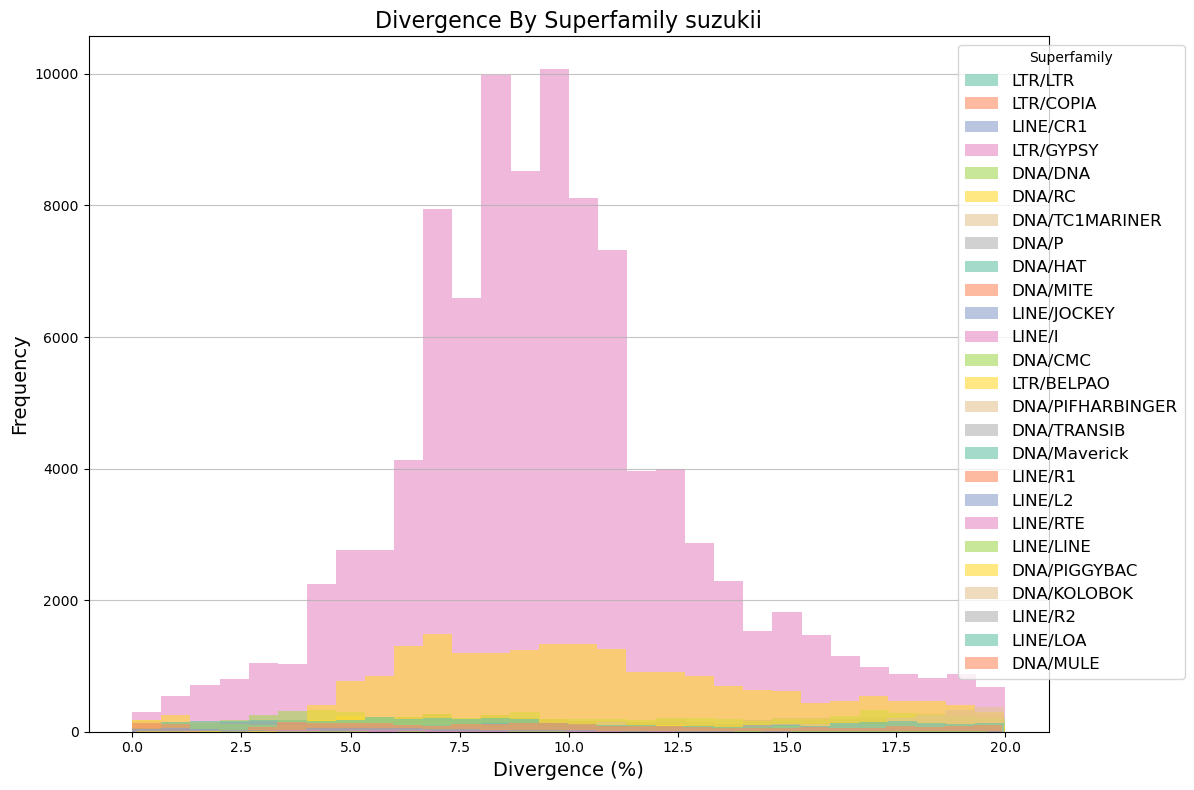

In [21]:
generate_histogram_by_class(annotation_ref, 'Divergence By Superfamily suzukii', 'divergence_by_superfamily_suzukii.png')

C:\Users\JuanG\AppData\Local\Temp\ipykernel_22408\3883592333.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)
C:\Users\JuanG\AppData\Local\Temp\ipykernel_22408\3883592333.py:14: UserWarning: 
The palette list has fewer values (22) than needed (26) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)


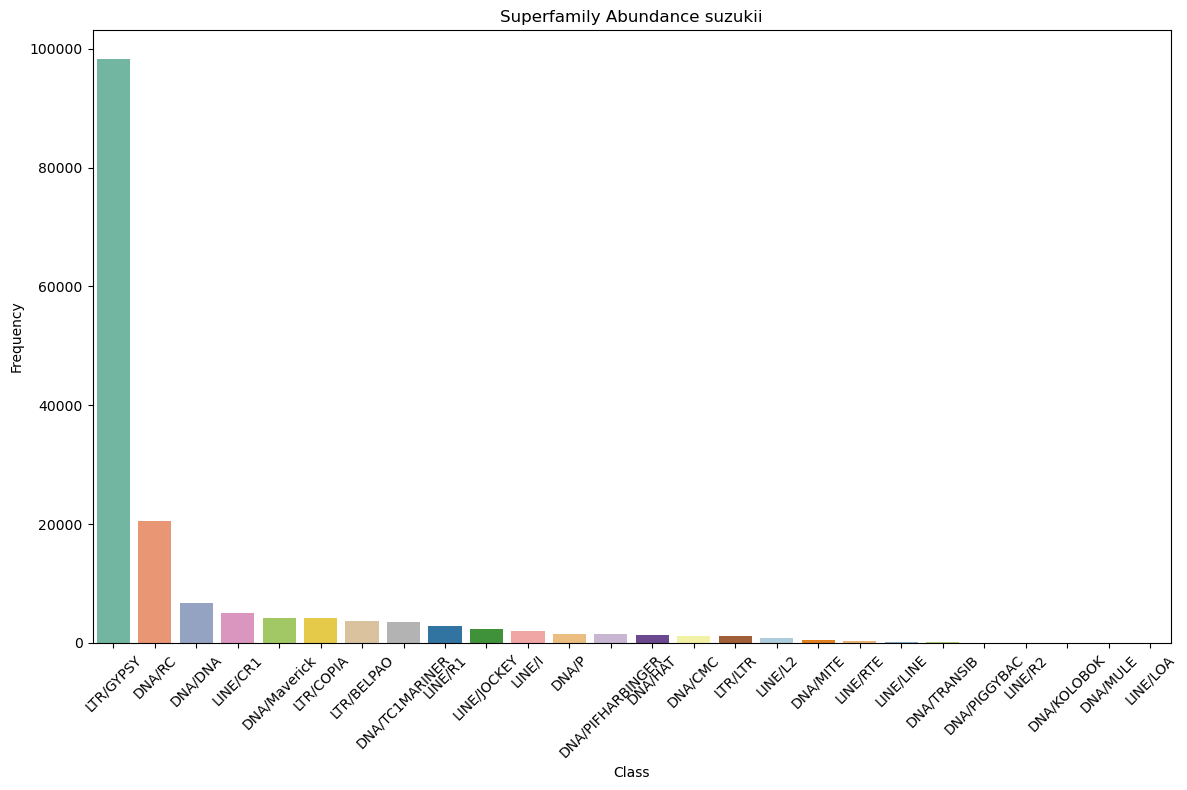

In [22]:
generate_class_frequency(annotation_ref,'Superfamily Abundance suzukii', 'superfamily_abundance_suzukii.png')

C:\Users\JuanG\AppData\Local\Temp\ipykernel_22408\4170447494.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Insertion_Time', data=df, palette='viridis')


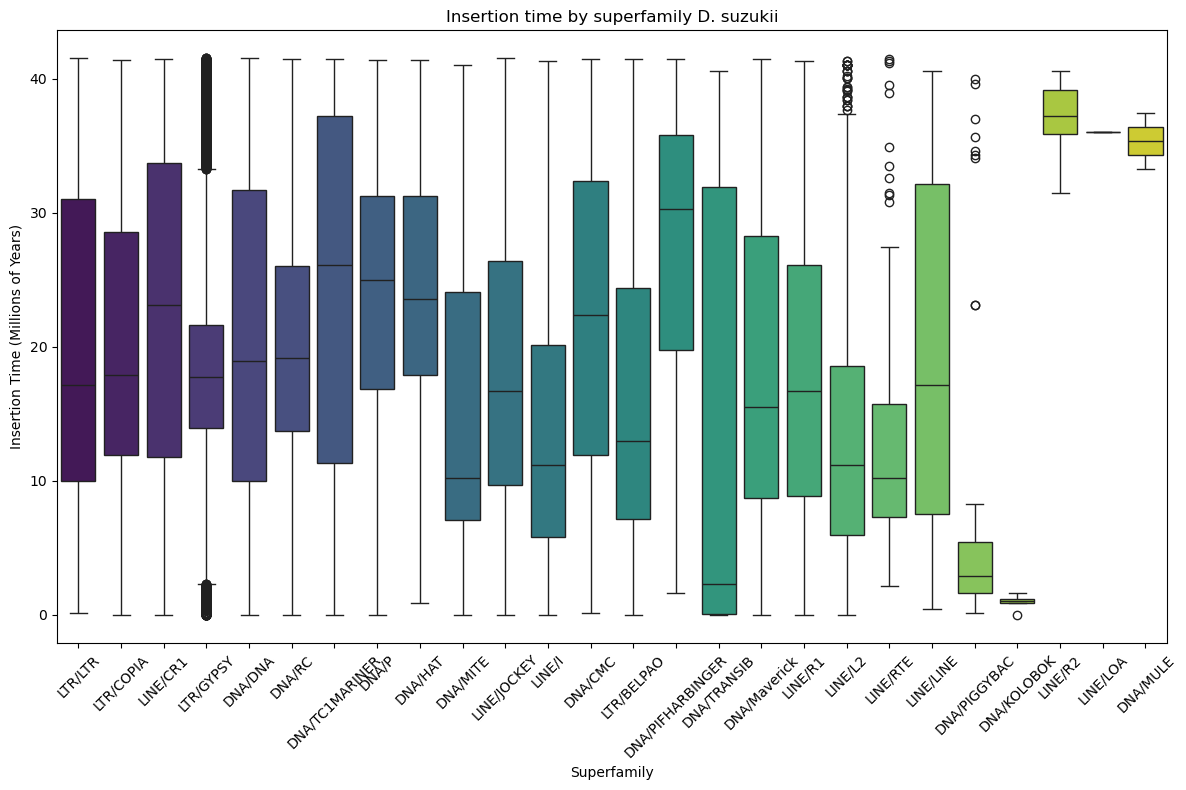

In [23]:
df_it_ref = calculate_insertion_time(annotation_ref, mutation_rate)
#plot_insertion_time(df_it_ref)
plot_insertion_time_by_class(df_it_ref, 'Insertion time by superfamily D. suzukii', 'insertion_time_suzukii.png')

In [ ]:
# Llamar a la función para graficar la distribución de TEs
#plot_te_distribution(annotation_ref, '../genomes/new.fna')

In [ ]:
#plot_te_distribution_density(annotation_ref, '../genomes/new.fna')

In [ ]:
#plot_te_distribution_heatmap(annotation_ref, '../genomes/newGCF_043229965.1_CBGP_Dsuzu_IsoJpt1.0_genomic.fna', 'Heatmap of TE Density in Main Chromosomes D. suzukii', 'density_by_chromosome_suzukii.png')

# Melanogaster

In [19]:
annotation_melano = read_annotation('melano_octfa.out')
annotation_melano.head()

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\2583104052.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)


,Repeat_ID,Divergence,Deletion,Insertion,Sequence_Name,Alignment_Start,Alignment_End,Element_Length,Orientation,Family_Name,Class,Base_Count,5'_Fragment_Length,3'_Fragment_Length,Additional_Info,Repeat_Count,Score
0,872,7.000,4.700,0.800,NC_004353.4,1563,1691,134,+,DNAREP1_DM,DNA/RC,572,705.0,(0),5,1,0.190
1,920/355,16.639,25.066,1.431,NC_004353.4,5057,5492,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),6/6,2,0.701
2,590,13.000,0.000,5.000,NC_004353.4,7131,7235,100,C,DNAREP1_DM,DNA/RC,(541),164.0,65,8,1,0.142
3,937/355,16.413,25.066,1.431,NC_004353.4,11838,12273,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),9/9,2,0.701
4,55699,0.300,1.400,0.200,NC_004353.4,13649,20087,6519,+,Quasimodo2_DM,LTR/GYPSY,1,6519.0,(0),11,1,No_ref_available


Calculando tamaño del genoma...
Tamaño del genoma: 143726002 pb
Suma total de longitud de TEs (con solapamientos): 33560169 pb
Sizes finales para gráfica: [np.float64(23.35010264878863), np.float64(76.64989735121137)]


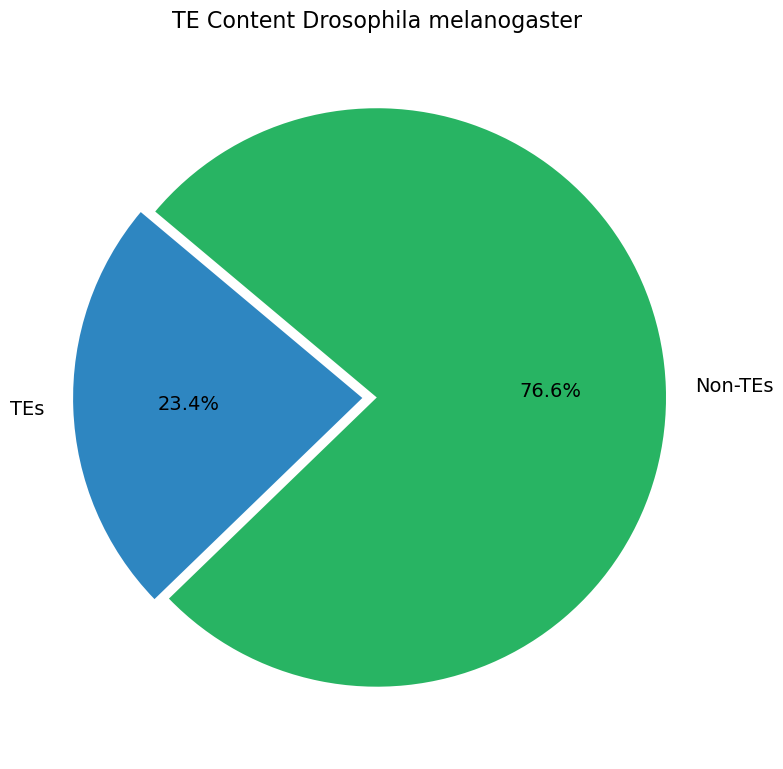

In [20]:
calculate_te_percentage_alternate(annotation_melano, 'D_melanogaster_GCF_000001215.4.fna', 'TE Content Drosophila melanogaster', 'te_content_melanogaster.png')

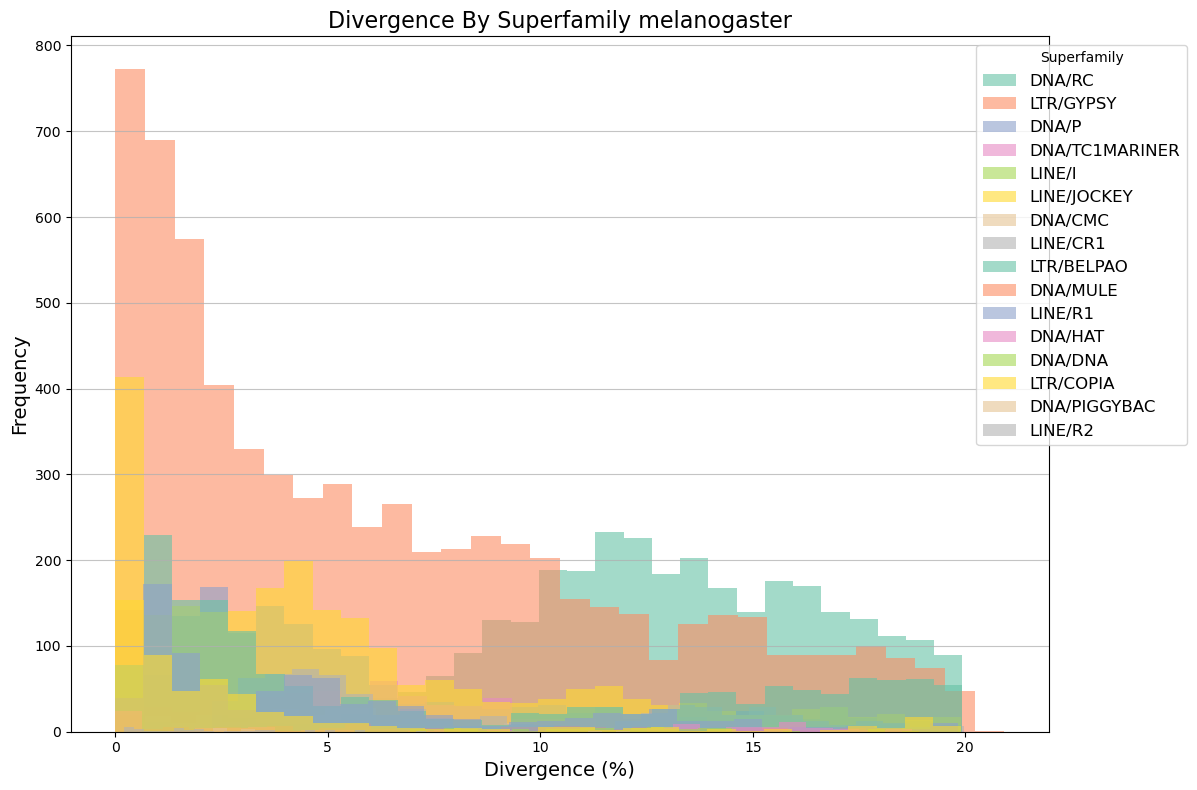

In [26]:
generate_histogram_by_class(annotation_melano, 'Divergence By Superfamily melanogaster', 'divergence_by_superfamily_melanogaster.png')

C:\Users\JuanG\AppData\Local\Temp\ipykernel_7280\3883592333.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)
C:\Users\JuanG\AppData\Local\Temp\ipykernel_7280\3883592333.py:14: UserWarning: The palette list has more values (22) than needed (16), which may not be intended.
  sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)


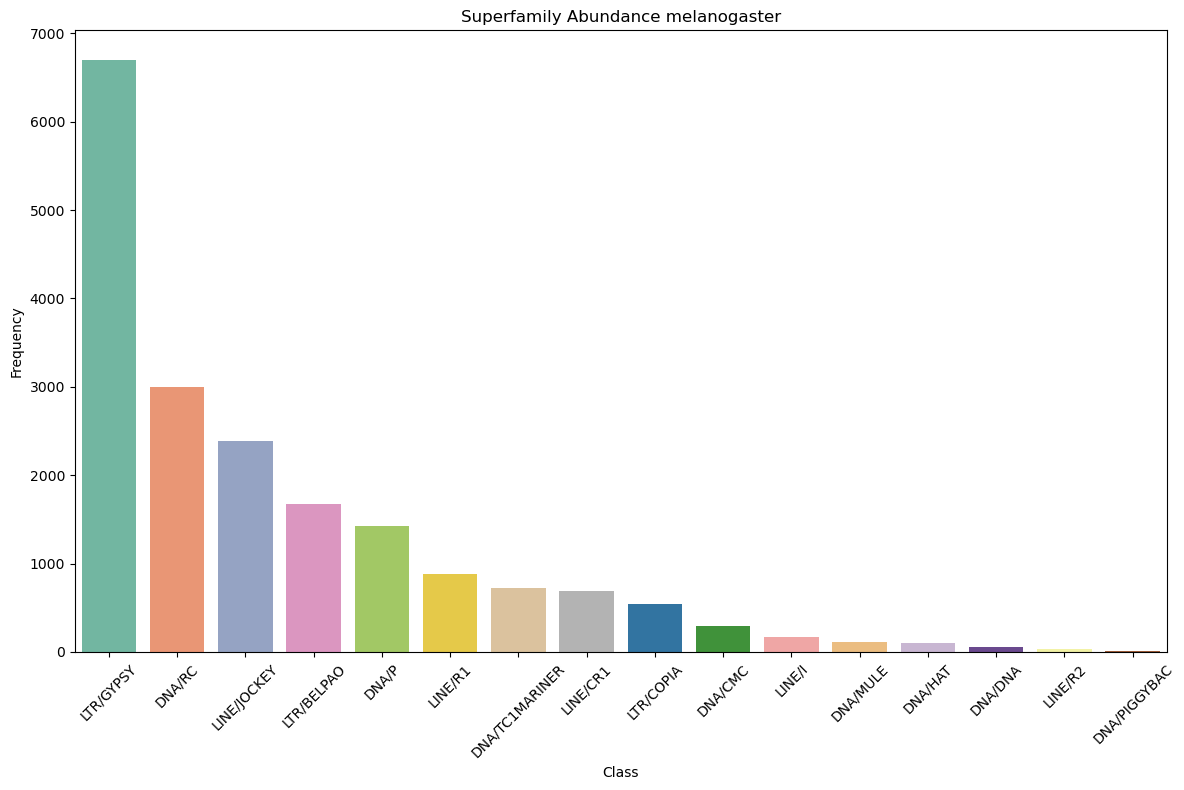

In [26]:
generate_class_frequency(annotation_melano, 'Superfamily Abundance melanogaster', 'superfamily_abundance_melanogaster.png')

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\4170447494.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Insertion_Time', data=df, palette='viridis')


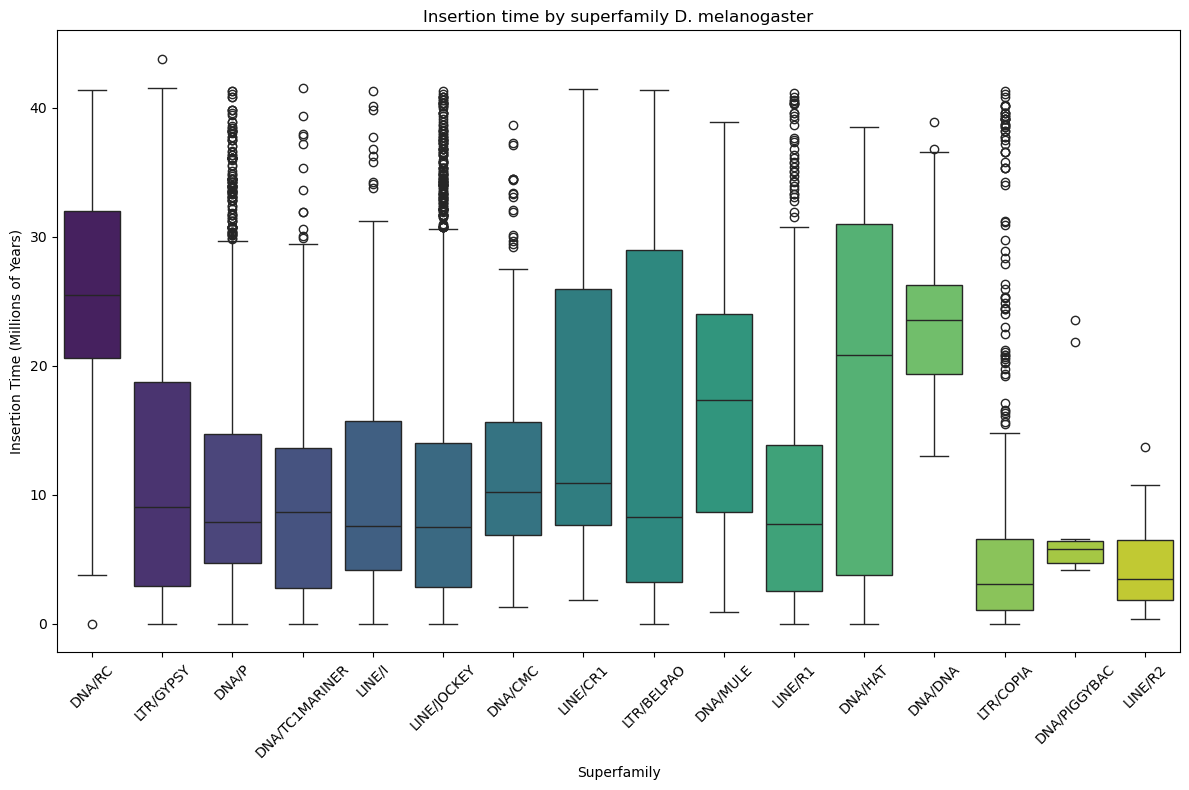

In [21]:
df_it_melano = calculate_insertion_time(annotation_melano, mutation_rate)
#plot_insertion_time(df_it_melano)
plot_insertion_time_by_class(df_it_melano, 'Insertion time by superfamily D. melanogaster', 'insertion_time_melanogaster.png')

In [ ]:
#plot_te_distribution_heatmap(annotation_melano, '../genomes/melano.fna', 'Heatmap of TE Density in Main Chromosomes D. melanogaster', 'density_by_chromosome_melanogaster.png')

# New Plots

In [22]:
te_annotation_df_suzukii = read_annotation('suzukii_GCF_043229965.1_octfa.out')
te_annotation_df_suzukii.head()

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\2583104052.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)


,Repeat_ID,Divergence,Deletion,Insertion,Sequence_Name,Alignment_Start,Alignment_End,Element_Length,Orientation,Family_Name,Class,Base_Count,5'_Fragment_Length,3'_Fragment_Length,Additional_Info,Repeat_Count,Score
0,10299,1.300,3.000,0.600,NC_092080.1,21824,23072,1269,C,nf_292_LTR_1,LTR/LTR,(0),1269,1,28,1,No_ref_available
1,2536/284,7.711,2.253,1.259,NC_092080.1,35610,44782,402,C,nf_26_COPIA_1,LTR/COPIA,(352),8153,4236,43/58,2,No_ref_available
2,886/366,16.849,0.000,0.000,NC_092080.1,35924,36254,214,+,nf_25_CR1_1,LINE/CR1,1565,1779,(6831),44/44,2,0.025
3,523,19.000,18.100,1.200,NC_092080.1,36339,36482,168,+,nf_205_CR1_2,LINE/CR1,1763,1930,(37),46,1,0.085
4,578,7.200,12.100,1.800,NC_092080.1,36975,37073,109,C,Gypsy-30_DWil-I_1,LTR/GYPSY,(261),5618,5510,48,1,No_ref_available


In [23]:
te_annotation_df_melano = read_annotation('melano_octfa.out')

te_annotation_df_melano.head()

C:\Users\JuanG\AppData\Local\Temp\ipykernel_3928\2583104052.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, comment='#', header=None, names=column_names)


,Repeat_ID,Divergence,Deletion,Insertion,Sequence_Name,Alignment_Start,Alignment_End,Element_Length,Orientation,Family_Name,Class,Base_Count,5'_Fragment_Length,3'_Fragment_Length,Additional_Info,Repeat_Count,Score
0,872,7.000,4.700,0.800,NC_004353.4,1563,1691,134,+,DNAREP1_DM,DNA/RC,572,705.0,(0),5,1,0.190
1,920/355,16.639,25.066,1.431,NC_004353.4,5057,5492,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),6/6,2,0.701
2,590,13.000,0.000,5.000,NC_004353.4,7131,7235,100,C,DNAREP1_DM,DNA/RC,(541),164.0,65,8,1,0.142
3,937/355,16.413,25.066,1.431,NC_004353.4,11838,12273,494,+,DNAREP1_DM,DNA/RC,3,705.0,(0),9/9,2,0.701
4,55699,0.300,1.400,0.200,NC_004353.4,13649,20087,6519,+,Quasimodo2_DM,LTR/GYPSY,1,6519.0,(0),11,1,No_ref_available


In [24]:
def calculate_te_content_percentage(te_annotation_df, genome_file):
    """
    Calcula el porcentaje de elementos transponibles (TEs) y el porcentaje de regiones que no son TEs
    en un genoma dado.

    Parámetros:
    - te_annotation_df: DataFrame con la anotación de TEs.
    - genome_file: Ruta al archivo FASTA del genoma.

    Retorna:
    - (te_percentage, non_te_percentage): Una tupla con el porcentaje de TEs y el porcentaje de Non-TEs.
    """
    # Calcular la longitud total del genoma
    total_genome_length = sum(len(record.seq) for record in SeqIO.parse(genome_file, 'fasta'))

    # Calcular la longitud total de los TEs usando las posiciones de alineamiento
    te_annotation_df['Actual_Length'] = te_annotation_df['Alignment_End'] - te_annotation_df['Alignment_Start'] + 1
    total_te_length = te_annotation_df['Actual_Length'].sum()

    # Calcular los porcentajes
    te_percentage = (total_te_length * 100) / total_genome_length
    non_te_percentage = 100 - te_percentage
    return te_percentage, non_te_percentage

In [25]:
def te_content_in_genome_by_species(te_annotation_df_suzukii, te_annotation_df_melano, genome_suzukii, genome_melano, plot_title, image_path):
    """
    Muestra un gráfico de barras agrupadas horizontal para comparar el contenido de TEs y Non-TEs
    en los genomas de D. suzukii y D. melanogaster, usando una paleta de colores personalizada.

    Parámetros:
    - te_annotation_df_suzukii: DataFrame con la anotación de TEs para D. suzukii.
    - te_annotation_df_melano: DataFrame con la anotación de TEs para D. melanogaster.
    - genome_suzukii: Ruta al archivo FASTA del genoma de D. suzukii.
    - genome_melano: Ruta al archivo FASTA del genoma de D. melanogaster.
    - plot_title: Título del gráfico.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra el gráfico de barras agrupadas horizontal.
    """

    # Calcular porcentajes para D. suzukii y D. melanogaster
    suzukii_te_percentage, suzukii_non_te_percentage = calculate_te_content_percentage(te_annotation_df_suzukii, genome_suzukii)
    melano_te_percentage, melano_non_te_percentage = calculate_te_content_percentage(te_annotation_df_melano, genome_melano)

    # Valores para cada especie
    suzukii_values = [suzukii_te_percentage, suzukii_non_te_percentage]
    melano_values = [melano_te_percentage, melano_non_te_percentage]

    # Etiquetas de las categorías
    categories = ['TEs', 'Non-TEs']

    # Configuración de posiciones para las barras agrupadas
    bar_width = 0.2  # Ancho de las barras delgado para un estilo minimalista
    y_positions = np.arange(len(categories))

    # Crear el gráfico
    fig, ax = plt.subplots(figsize=(8, 4))

    # Paleta de colores personalizada
    custom_palette = ["#66c2a5", "#fc8d62"]  # Colores para D. suzukii y D. melanogaster respectivamente

    # Dibujar barras para D. suzukii
    bars_suzukii = ax.barh(y_positions - bar_width/2, suzukii_values, height=bar_width, color=custom_palette[0], label=r'$\mathit{D. \ suzukii}$'
)

    # Dibujar barras para D. melanogaster
    bars_melano = ax.barh(y_positions + bar_width/2, melano_values, height=bar_width, color=custom_palette[1], label=r'$\mathit{D. \ melanogaster}$'
)

    # Añadir el porcentaje exacto sobre cada barra
    for bar in bars_suzukii:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
                va='center', ha='left', fontsize=10, color='black')

    for bar in bars_melano:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
                va='center', ha='left', fontsize=10, color='black')

    # Configuración de etiquetas y título
    ax.set_yticks(y_positions)
    ax.set_yticklabels(categories, fontsize=12, fontweight='bold')
    ax.set_xlabel('Percentage', fontsize=12)
    #ax.set_title(plot_title, fontsize=14, pad=15)

    # Leyenda ajustada para no sobreponerse a las barras
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)

    # Estilo minimalista (ocultar cuadrícula y ajustar ejes)
    ax.grid(False)  # Eliminar la cuadrícula
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')

    # Guardar y mostrar el gráfico
    plt.tight_layout()
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()

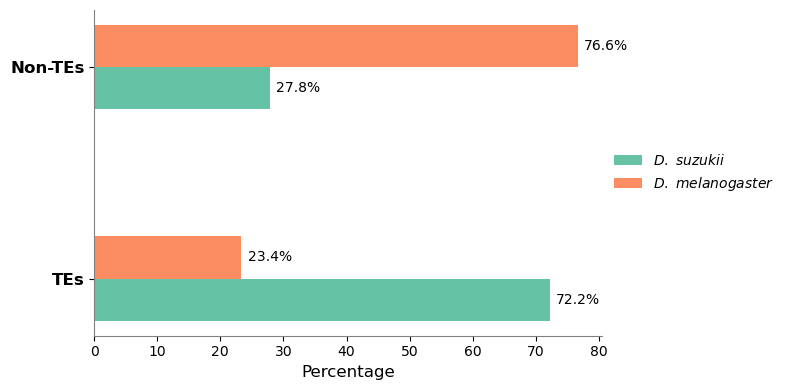

In [32]:
te_content_in_genome_by_species(
    te_annotation_df_suzukii,
    te_annotation_df_melano,
    'D_suzukii_GCF_043229965.1.fna',
    'D_melanogaster_GCF_000001215.4.fna',
    'TE content in D. suzukii and D. melanogaster genomes',
    'te_content_comparison_one_plot.png'
)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_repeatmasker_out_superfamilies(file_path):
    """
    Carga y procesa un archivo .out de RepeatMasker para obtener la columna de superfamilia.
    """
    # Cargar datos ignorando líneas iniciales (cabecera de 3 líneas)
    df = pd.read_csv(file_path, sep="\s+", engine='python', header=None)

    # RepeatMasker .out tiene el nombre del TE y su clase/superfamilia en la columna 10
    # En algunos casos, esta puede estar en la columna 10 o 11 dependiendo del formato
    # Aquí tomamos por convención las columnas esperadas
    df.columns = list(range(len(df.columns)))
    df['Superfamily'] = df[10].astype(str)

    # Si está en formato Class/Superfamily, lo dejamos así. Si no, lo limpiamos
    df['Superfamily'] = df['Superfamily'].apply(lambda x: x if '/' in x else 'Unclassified/Unclassified')

    # Calcular longitud del elemento
    df['Length'] = df[7]

    return df[['Superfamily', 'Length']]


def calculate_superfamily_proportions(df, genome_size):
    """
    Calcula proporciones del genoma ocupado por cada orden de TE,
    y agrega la categoría 'Non-TE' como el complemento.
    """
    # Paso 1: suma de longitudes por orden
    order_lengths = df.groupby('Superfamily')['Length'].sum()

    # Paso 2: suma total de TE
    total_te_length = order_lengths.sum()

    # Paso 3: calcular longitud Non-TE
    non_te_length = max(genome_size - total_te_length, 0)

    # Paso 4: combinar todo en un solo Series de longitudes
    full_lengths = order_lengths.copy()
    full_lengths['Non-TE'] = non_te_length

    # Paso 5: convertir a proporciones
    proportions = full_lengths / genome_size

    print(proportions)
    return proportions.sort_values(ascending=False)

def plot_superfamily_piecharts_superfamilies(file_suzukii, file_melanogaster, genome_size_suzukii, genome_size_melanogaster):
    import matplotlib.pyplot as plt

    # Leer y procesar archivos
    df_suz = parse_repeatmasker_out_superfamilies(file_suzukii)
    df_mel = parse_repeatmasker_out_superfamilies(file_melanogaster)

    # Calcular proporciones relativas al tamaño del genoma
    prop_suz = calculate_superfamily_proportions(df_suz, genome_size_suzukii)
    prop_mel = calculate_superfamily_proportions(df_mel, genome_size_melanogaster)

    # Unificar órdenes
    all_orders = sorted(set(prop_suz.index).union(prop_mel.index))
    prop_suz = prop_suz.reindex(all_orders, fill_value=0)
    prop_mel = prop_mel.reindex(all_orders, fill_value=0)

    # Crear figura
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot D. suzukii con porcentajes fuera del pastel
    explode_suz = [0.05 for i in range(len(all_orders))]
    # Función para ocultar valores cercanos a 0
    def autopct_format(pct):
        return f'{pct:.1f}%' if pct > 0 else ''  # Oculta valores <0.5%

    wedges_suz, texts_suz, autotexts_suz = axes[0].pie(
        prop_suz, labels=None, startangle=90, autopct='%1.1f%%', pctdistance=1.1, explode=explode_suz
    )
    axes[0].set_title('A. D. suzukii', fontsize=30, fontstyle='italic')


    # Plot D. melanogaster
    # Crear explode solo para D. melanogaster
    explode_mel = [0.05 for i in range(len(all_orders))]
    prop_mel_plot = prop_mel.copy()
    prop_mel_plot['DNA/Maverick'] = 0

    # Función para ocultar valores cercanos a 0
    def autopct_format(pct):
        return f'{pct:.1f}%' if pct > 0 else ''  # Oculta valores <0.5%

    wedges_mel, texts_mel, autotexts_mel = axes[1].pie(
        prop_mel_plot, labels=None, startangle=90, autopct=autopct_format,
        pctdistance=1.1, explode=explode_mel
    )
    axes[1].set_title('B. D. melanogaster', fontsize=30, fontstyle='italic')

    # Leyenda (solo una, basada en el orden común)
    fig.legend(wedges_suz, all_orders, title="Order", loc='center right', bbox_to_anchor=(1, 0.5))

    # Estilo de los textos de porcentaje
    for autotext in autotexts_suz + autotexts_mel:
        autotext.set_fontsize(10)
        autotext.set_color('black')

    plt.tight_layout()
    plt.subplots_adjust(right=0.8)
    plt.show()

Superfamily
DNA/CMC             2.252769e-03
DNA/DNA             6.821128e-03
DNA/HAT             1.078121e-03
DNA/KOLOBOK         3.033508e-05
DNA/MITE            8.282585e-04
DNA/MULE            1.945139e-06
DNA/Maverick        3.158464e-02
DNA/P               1.522341e-03
DNA/PIFHARBINGER    2.547944e-03
DNA/PIGGYBAC        1.980929e-04
DNA/RC              3.386641e-02
DNA/TC1MARINER      5.356543e-03
DNA/TRANSIB         3.835878e-04
LINE/CR1            1.847001e-02
LINE/I              8.674765e-03
LINE/JOCKEY         9.676712e-03
LINE/L2             3.893560e-03
LINE/LINE           1.596099e-04
LINE/LOA            3.393499e-07
LINE/R1             1.794978e-02
LINE/R2             1.749576e-05
LINE/RTE            1.089026e-03
LTR/BELPAO          2.480997e-02
LTR/COPIA           7.143101e-03
LTR/GYPSY           1.004334e-01
LTR/LTR             2.275628e-03
Non-TE              7.189345e-01
Name: Length, dtype: float64
Superfamily
DNA/CMC           0.001913
DNA/DNA           0.000088
DN

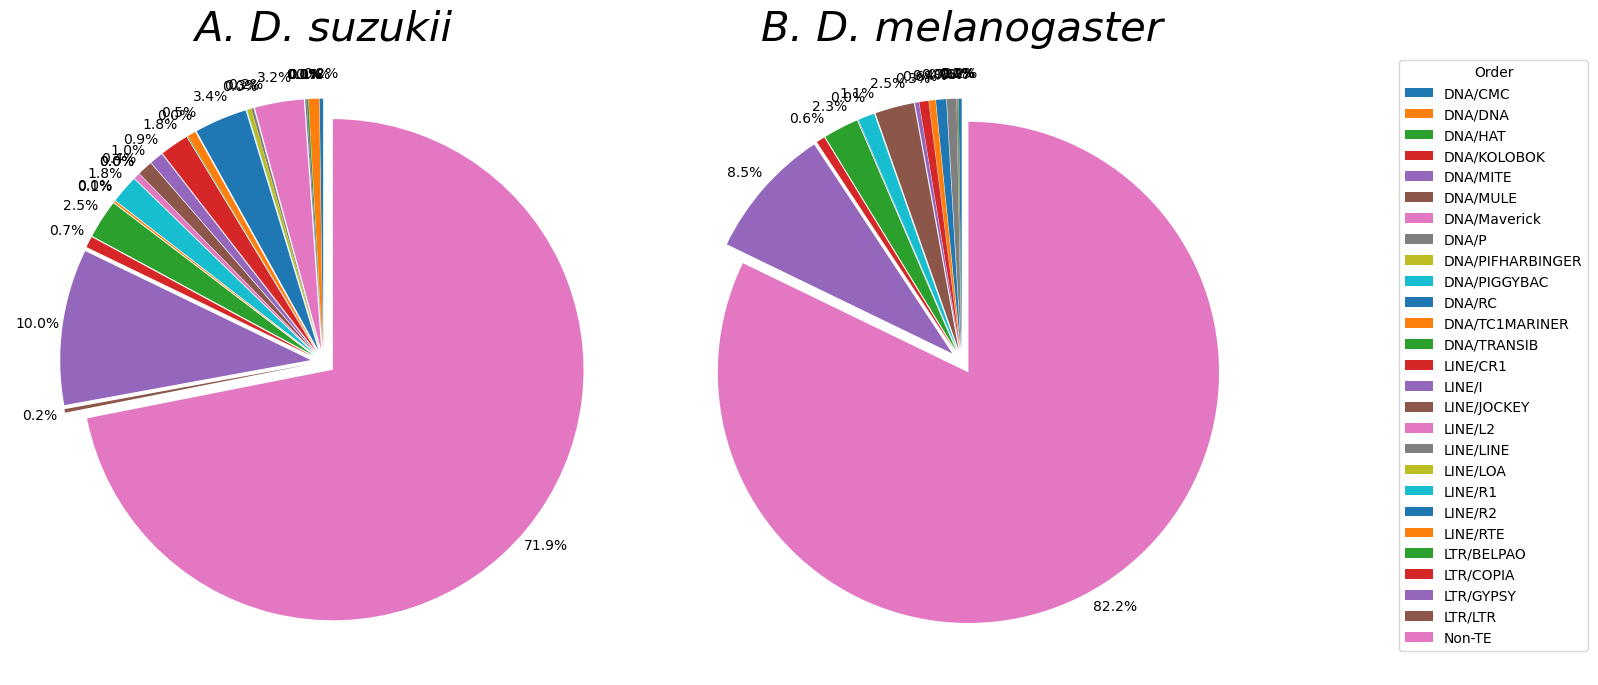

In [27]:
genome_size_suzukii = 285840699
genome_size_melanogaster = 145523498

plot_superfamily_piecharts_superfamilies("suzukii_GCF_043229965.1_octfa.out", "melano_octfa.out", genome_size_suzukii, genome_size_melanogaster)

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def parse_repeatmasker_out_orders(file_path):
    """
    Carga y procesa un archivo .out de RepeatMasker para obtener el orden de cada elemento transponible
    (incluyendo casos especiales como DNA/RC y DNA/Maverick) y su longitud.
    """
    import pandas as pd

    # Leer archivo, omitiendo el encabezado estándar de RepeatMasker (.out)
    df = pd.read_csv(file_path, sep="\t", header=None, engine='python')

    if df.shape[1] < 11:
        raise ValueError("El archivo no tiene el formato estándar esperado de RepeatMasker .out")

    # Extraer clase/superfamilia
    class_sf = df[10].astype(str)

    # Clasificar orden, con manejo de casos especiales
    def extract_order(x):
        if 'DNA/RC' in x:
            return 'RC/Helitron'
        elif 'DNA/Maverick' in x:
            return 'DNA/Maverick'
        elif '/' in x:
            return x.split('/')[0]
        else:
            return 'Unclassified'

    df['Order'] = class_sf.apply(extract_order)

    # Calcular longitud del fragmento anotado
    df['Length'] = df[7]

    return df[['Order', 'Length']]

def calculate_order_proportions(df, genome_size):
    """
    Calcula proporciones del genoma ocupado por cada orden de TE,
    y agrega la categoría 'Non-TE' como el complemento.
    """
    # Paso 1: suma de longitudes por orden
    order_lengths = df.groupby('Order')['Length'].sum()

    # Paso 2: suma total de TE
    total_te_length = order_lengths.sum()

    # Paso 3: calcular longitud Non-TE
    non_te_length = max(genome_size - total_te_length, 0)

    # Paso 4: combinar todo en un solo Series de longitudes
    full_lengths = order_lengths.copy()
    full_lengths['Non-TE'] = non_te_length

    # Paso 5: convertir a proporciones
    proportions = full_lengths / genome_size

    print(proportions)
    return proportions.sort_values(ascending=False)

def parse_repeatmasker_out_superfamilies(file_path):
    """
    Carga y procesa un archivo .out de RepeatMasker para obtener la columna de superfamilia.
    """
    # Cargar datos ignorando líneas iniciales (cabecera de 3 líneas)
    df = pd.read_csv(file_path, sep="\s+", engine='python', header=None)

    # RepeatMasker .out tiene el nombre del TE y su clase/superfamilia en la columna 10
    # En algunos casos, esta puede estar en la columna 10 o 11 dependiendo del formato
    # Aquí tomamos por convención las columnas esperadas
    df.columns = list(range(len(df.columns)))
    df['Superfamily'] = df[10].astype(str)

    # Si está en formato Class/Superfamily, lo dejamos así. Si no, lo limpiamos
    df['Superfamily'] = df['Superfamily'].apply(lambda x: x if '/' in x else 'Unclassified/Unclassified')

    # Calcular longitud del elemento
    df['Length'] = df[7]

    return df[['Superfamily', 'Length']]


def calculate_superfamily_proportions(df, genome_size):
    """
    Calcula proporciones del genoma ocupado por cada orden de TE,
    y agrega la categoría 'Non-TE' como el complemento.
    """
    # Paso 1: suma de longitudes por orden
    order_lengths = df.groupby('Superfamily')['Length'].sum()

    # Paso 2: suma total de TE
    total_te_length = order_lengths.sum()

    # Paso 3: calcular longitud Non-TE
    non_te_length = max(genome_size - total_te_length, 0)

    # Paso 4: combinar todo en un solo Series de longitudes
    full_lengths = order_lengths.copy()
    full_lengths['Non-TE'] = non_te_length

    # Paso 5: convertir a proporciones
    proportions = full_lengths / genome_size

    print(proportions)
    return proportions.sort_values(ascending=False)

def plot_superfamily_piecharts_final_fix_v3(file_suzukii, file_melanogaster, genome_size_suzukii, genome_size_melanogaster):
    
    # 1. Procesar datos
    df_suz = parse_repeatmasker_out_orders(file_suzukii)
    df_mel = parse_repeatmasker_out_orders(file_melanogaster)

    prop_suz = calculate_order_proportions(df_suz, genome_size_suzukii)
    prop_mel = calculate_order_proportions(df_mel, genome_size_melanogaster)

    # 2. Unificar índices y colores
    all_orders = sorted(set(prop_suz.index).union(prop_mel.index))
    prop_suz = prop_suz.reindex(all_orders, fill_value=0)
    prop_mel = prop_mel.reindex(all_orders, fill_value=0)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(all_orders))]

    # ⭐ Layout inteligente
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)


    # --- FUNCIÓN DE ETIQUETAS ---
    def add_callout_labels(ax, wedges, proportions, threshold=5.0):

        label_distance = 1.25
        inside_distance = 0.65

        for i, wedge in enumerate(wedges):

            pct = proportions.iloc[i] * 100
            if pct <= 0.1:
                continue
            
            ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = np.cos(np.deg2rad(ang))
            y = np.sin(np.deg2rad(ang))
            text_val = f"{pct:.1f}%"
            
            if pct >= threshold:
                ax.text(
                    x * inside_distance,
                    y * inside_distance,
                    text_val,
                    ha='center',
                    va='center',
                    fontsize=18,
                    fontweight='bold',
                    color='white'
                )
            else:
                align = 'left' if x > 0 else 'right'
                
                ax.annotate(
                    text_val,
                    xy=(x, y),
                    xytext=(x * label_distance, y * label_distance),
                    horizontalalignment=align,
                    fontsize=18,
                    color='black',
                    weight='bold',
                    arrowprops=dict(arrowstyle="-", color="black")
                )

    # --- GRÁFICO 1 ---
    wedges_suz, _ = axes[0].pie(
        prop_suz,
        labels=None,
        startangle=90,
        colors=colors,
        radius=1.1
    )
    
    axes[0].set_title('D. suzukii', fontsize=30, fontstyle='italic', pad=35)
    add_callout_labels(axes[0], wedges_suz, prop_suz)

    # --- GRÁFICO 2 ---
    explode_mel = [
        0.08 if order in ['RC/Helitron', 'DNA/Maverick'] and prop_mel.loc[order] > 0 else 0
        for order in all_orders
    ]

    wedges_mel, _ = axes[1].pie(
        prop_mel,
        labels=None,
        startangle=90,
        explode=explode_mel,
        colors=colors,
        radius=1.1
    )
    
    axes[1].set_title('D. melanogaster', fontsize=30, fontstyle='italic', pad=35)
    add_callout_labels(axes[1], wedges_mel, prop_mel)

    # --- LEYENDA ---
    legend_labels = []
    for order in all_orders:
        val_suz = prop_suz.loc[order] * 100
        val_mel = prop_mel.loc[order] * 100
        legend_labels.append(f"{order} ({val_suz:.1f}% | {val_mel:.1f}%)")

    fig.legend(
        handles=[plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(colors))],
        labels=legend_labels,
        title="Order (Suz | Mel)",
        loc='center right',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=13
    )
    
    # Guardar
    plt.savefig('abundance_suzukii_vs_melano_final_v3.png', dpi=300, bbox_inches='tight')
    plt.show()

Order
DNA             0.021021
DNA/Maverick    0.031585
LINE            0.059931
LTR             0.134662
RC/Helitron     0.033866
Non-TE          0.718935
Name: Length, dtype: float64
Order
DNA            0.013489
LINE           0.044589
LTR            0.113598
RC/Helitron    0.006551
Non-TE         0.821773
Name: Length, dtype: float64


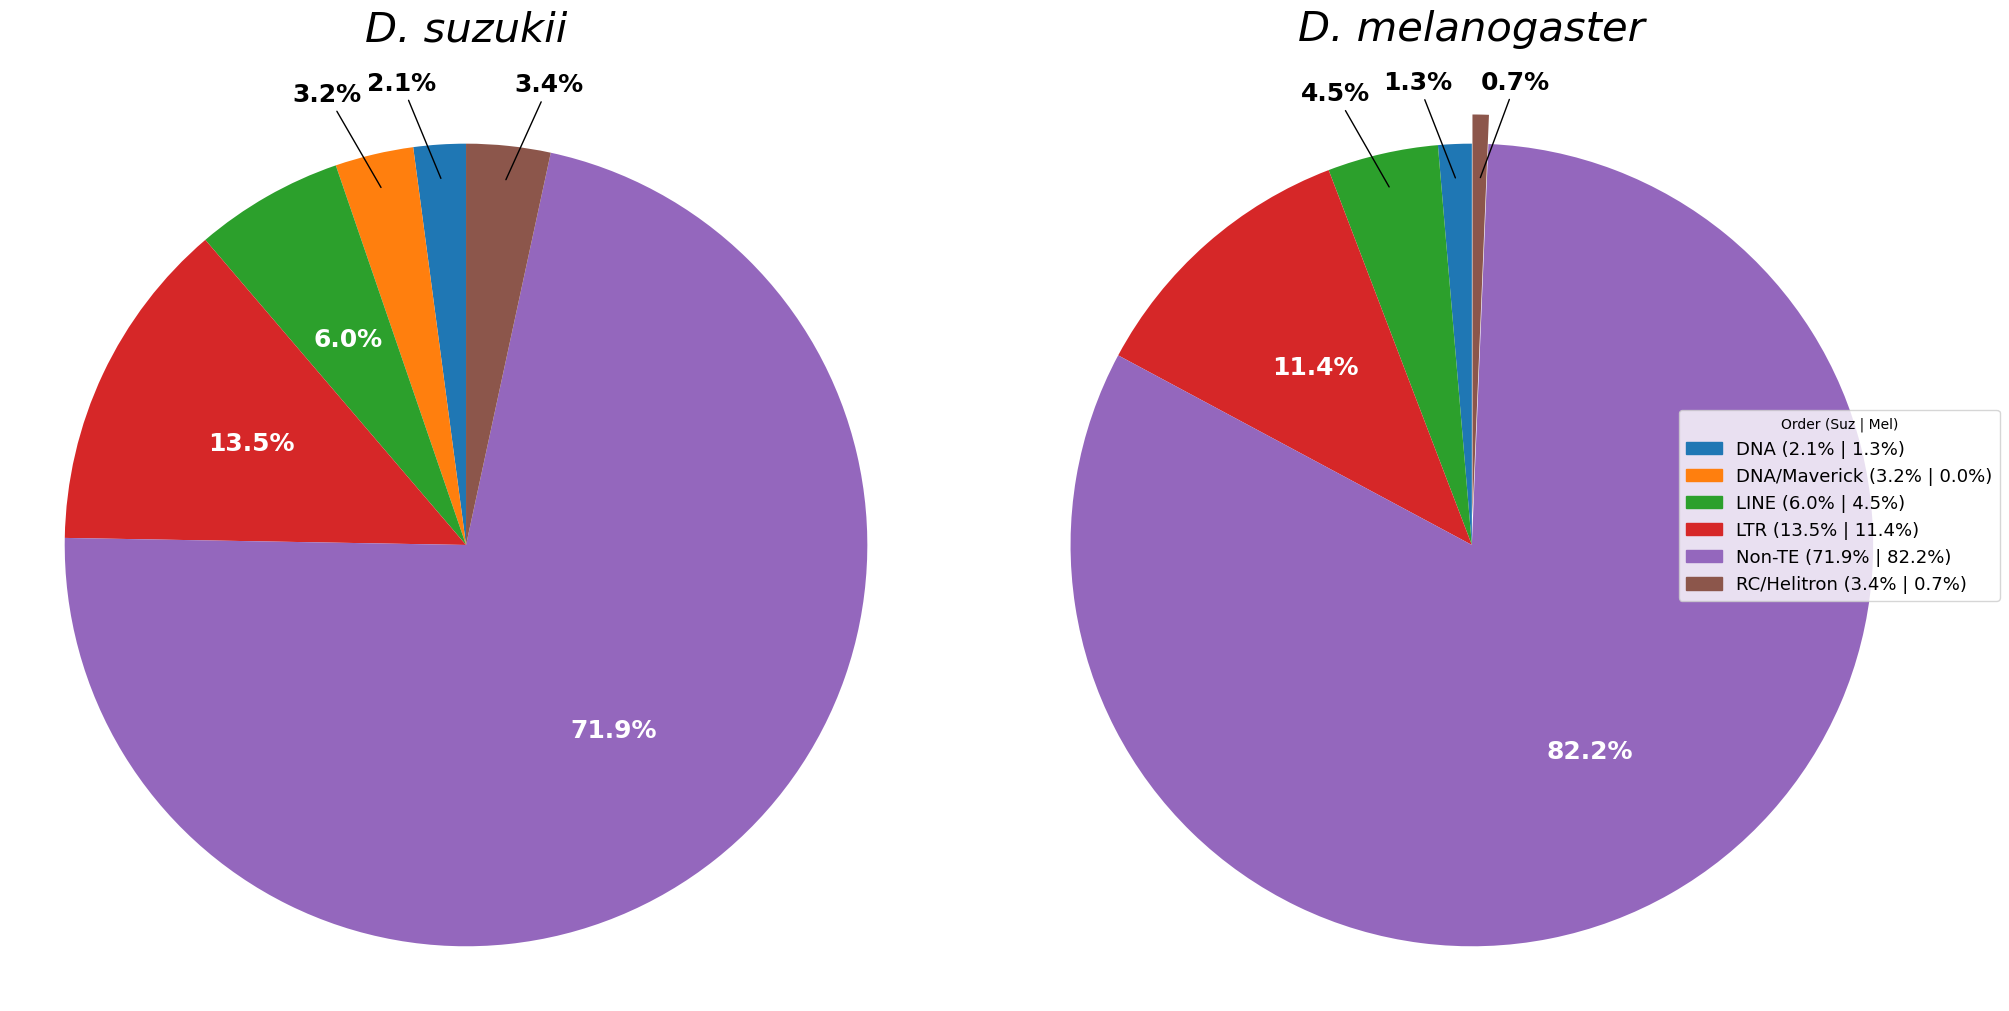

In [29]:
genome_size_suzukii = 285840699
genome_size_melanogaster = 145523498

plot_superfamily_piecharts_final_fix_v3("suzukii_GCF_043229965.1_octfa.out", "melano_octfa.out", genome_size_suzukii, genome_size_melanogaster)

In [30]:
def generate_divergent_bar_chart(df_suzukii, df_melanogaster, plot_title, image_path):
    """
    Genera un gráfico de barras divergentes para comparar la frecuencia de superfamilias entre
    D. suzukii y D. melanogaster en un único gráfico.

    Parámetros:
    - df_suzukii: DataFrame con la columna 'Class' para la anotación de D. suzukii.
    - df_melanogaster: DataFrame con la columna 'Class' para la anotación de D. melanogaster.
    - plot_title: Título general del gráfico.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra y guarda la imagen con un único gráfico divergente.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # Contar las frecuencias de cada superfamilia en cada DataFrame
    suzukii_counts = df_suzukii['Class'].value_counts()
    melanogaster_counts = df_melanogaster['Class'].value_counts()

    # Crear un DataFrame combinado con valores de frecuencia
    superfamilies = sorted(set(suzukii_counts.index).union(set(melanogaster_counts.index)))
    combined_df = pd.DataFrame({
        'Superfamily': superfamilies,
        'D. suzukii': [suzukii_counts.get(sf, 0) for sf in superfamilies],
        'D. melanogaster': [melanogaster_counts.get(sf, 0) for sf in superfamilies]
    })

    # Configuración del gráfico
    plt.figure(figsize=(18, 10))  # Ampliar el ancho del gráfico

    # Dibujar barras horizontales divergentes
    y_positions = np.arange(len(combined_df['Superfamily']))
    plt.barh(y_positions, combined_df['D. suzukii'], color="#66c2a5", label=r'$\mathit{D. \ suzukii}$')
    plt.barh(y_positions, -combined_df['D. melanogaster'], color="#fc8d62", label=r'$\mathit{D. \ melanogaster}$')

    # Fijar límites del eje x
    plt.xlim(-11000, 103500)  # Izquierda fija en -10,000 y derecha fija en 50,000

    # Ajustar márgenes para texto dinámicamente
    margin = 50000 * 0.02  # Margen basado en el límite máximo derecho

    # Añadir etiquetas de texto sobre cada barra (siempre positivas)
    for i, (suzukii, melanogaster) in enumerate(zip(combined_df['D. suzukii'], combined_df['D. melanogaster'])):
        # Colocar texto para D. suzukii
        x_position_suzukii = suzukii + margin
        plt.text(x_position_suzukii, i, f"{suzukii}", va='center', ha='left', fontsize=11)

        # Colocar texto para D. melanogaster como positivo
        x_position_melanogaster = -melanogaster - margin
        adjusted_position = max(x_position_melanogaster, -10000 + margin * 2)  # Asegurarse de que no haga overlap
        plt.text(adjusted_position, i, f"{abs(melanogaster)}", va='center', ha='right', fontsize=11)

    # Configurar etiquetas del eje X siempre positivas y redondeadas
    x_ticks_suzukii = np.linspace(0, 100000, 6)  # Etiquetas hasta 50,000
    x_ticks_melanogaster = np.linspace(0, 10000, 3)  # Etiquetas hasta 10,000 en el lado izquierdo
    plt.xticks(
        ticks=np.concatenate((-x_ticks_melanogaster[1:][::-1], x_ticks_suzukii)),
        labels=[f"{int(round(abs(x)))}" for x in np.concatenate((-x_ticks_melanogaster[1:][::-1], x_ticks_suzukii))]
    )

    # Configurar etiquetas y título
    plt.yticks(y_positions, combined_df['Superfamily'], fontsize=14)
    plt.axvline(0, color='black', linewidth=0.8)  # Línea central en 0
    #plt.title(plot_title, fontsize=16, fontweight='bold')
    plt.xlabel('Frequency', fontsize=13)

    # Quitar la cuadrícula
    plt.grid(False)

    # Mover la leyenda fuera del área de barras
    plt.legend(title='Species', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

    # Ajustar márgenes del gráfico para usar el máximo ancho disponible
    plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.15)

    # Guardar y mostrar el gráfico
    plt.tight_layout()
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()
    plt.close()

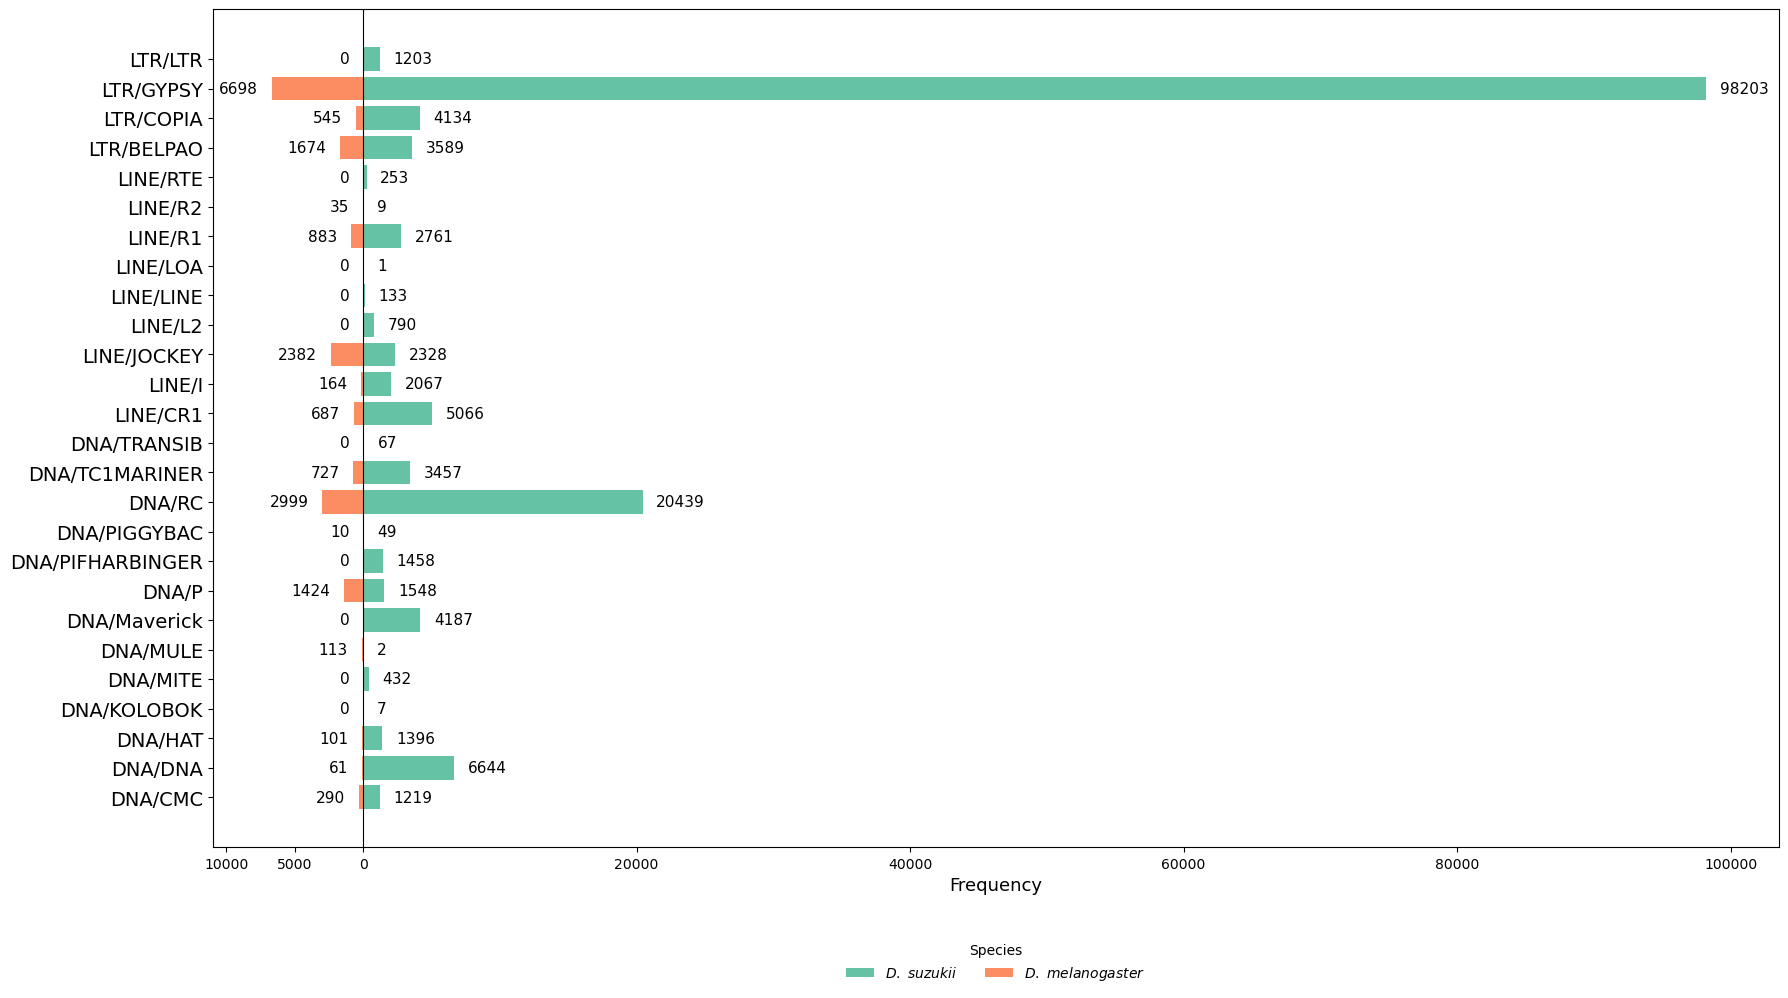

In [38]:
generate_divergent_bar_chart(te_annotation_df_suzukii, te_annotation_df_melano,
                        'Superfamily Abundance D. suzukii vs D. melanogaster',
                        'superfamily_abundance_comparison.png')

In [31]:
df_it_suz = calculate_insertion_time(te_annotation_df_suzukii, mutation_rate)
df_it_melanogaster = calculate_insertion_time(te_annotation_df_melano, mutation_rate)

df_it_suz.head()
print(te_annotation_df_suzukii['Insertion_Time'].head())

0     2.341783
1    14.530090
2    34.077460
3    39.125414
4    13.516864
Name: Insertion_Time, dtype: float64


In [40]:
def plot_insertion_time_by_class_one_plot(df_suzukii, df_melanogaster, plot_title, image_path):
    """
    Genera un boxplot horizontal de tiempos de inserción por clase para comparar D. suzukii y D. melanogaster,
    ordenando las clases de forma ascendente por el tiempo de inserción promedio de D. suzukii.
    Las superfamilias presentes solo en D. melanogaster aparecerán al final.

    Parámetros:
    - df_suzukii: DataFrame de D. suzukii con columnas 'Class' y 'Insertion_Time'.
    - df_melanogaster: DataFrame de D. melanogaster con columnas 'Class' y 'Insertion_Time'.
    - plot_title: Título del gráfico.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra y guarda un gráfico de boxplots horizontales agrupados.
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Eliminar filas con valores nulos en la columna 'Class' en ambos DataFrames
    df_suzukii = df_suzukii.dropna(subset=['Class']).copy()
    df_melanogaster = df_melanogaster.dropna(subset=['Class']).copy()

    # Normalizar los nombres de las clases (ej. eliminar espacios, poner en minúsculas si necesario)
    df_suzukii['Class'] = df_suzukii['Class'].str.strip()
    df_melanogaster['Class'] = df_melanogaster['Class'].str.strip()

    # Obtener todas las clases únicas de ambos DataFrames
    suzukii_classes = df_suzukii['Class'].unique()
    melanogaster_classes = df_melanogaster['Class'].unique()
    all_classes = pd.concat([df_suzukii['Class'], df_melanogaster['Class']]).unique()

    # Calcular el orden de las clases según el tiempo promedio de inserción en D. suzukii
    ordered_classes_suzukii = (
        df_suzukii.groupby('Class', observed=True)['Insertion_Time']
        .mean()
        .sort_values()
        .index
    )

    # Agregar las clases exclusivas de melanogaster al final
    ordered_classes = list(ordered_classes_suzukii) + [
        cls for cls in melanogaster_classes if cls not in suzukii_classes
    ]

    # Establecer el orden de las clases en ambos DataFrames
    df_suzukii['Class'] = pd.Categorical(df_suzukii['Class'], categories=ordered_classes, ordered=True)
    df_melanogaster['Class'] = pd.Categorical(df_melanogaster['Class'], categories=ordered_classes, ordered=True)

    # Agregar una columna para identificar la especie
    #df_suzukii['Species'] = 'D. suzukii'
    #df_melanogaster['Species'] = 'D. melanogaster'
    df_suzukii['Species'] = r'$\mathit{D. \ suzukii}$'
    df_melanogaster['Species'] = r'$\mathit{D. \ melanogaster}$'

    # Concatenar ambos DataFrames
    combined_df = pd.concat([df_suzukii, df_melanogaster])

    # Configuración del gráfico
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=combined_df, x='Class', y='Insertion_Time', hue="Species", palette=["#66c2a5", "#fc8d62"])

    # Configuración de etiquetas y título
    #plt.title(plot_title, fontsize=16)
    plt.xlabel('Superfamily')
    plt.ylabel('Insertion Time (Million of Years)')
    plt.xticks(rotation=90)
    plt.legend(title='Species', loc='upper left', bbox_to_anchor=(1.05, 1))  # Mueve la leyenda fuera del área del gráfico
    plt.tight_layout()

    # Guardar la gráfica en la ruta especificada
    plt.savefig(image_path, format='png', dpi=300)
    plt.show()

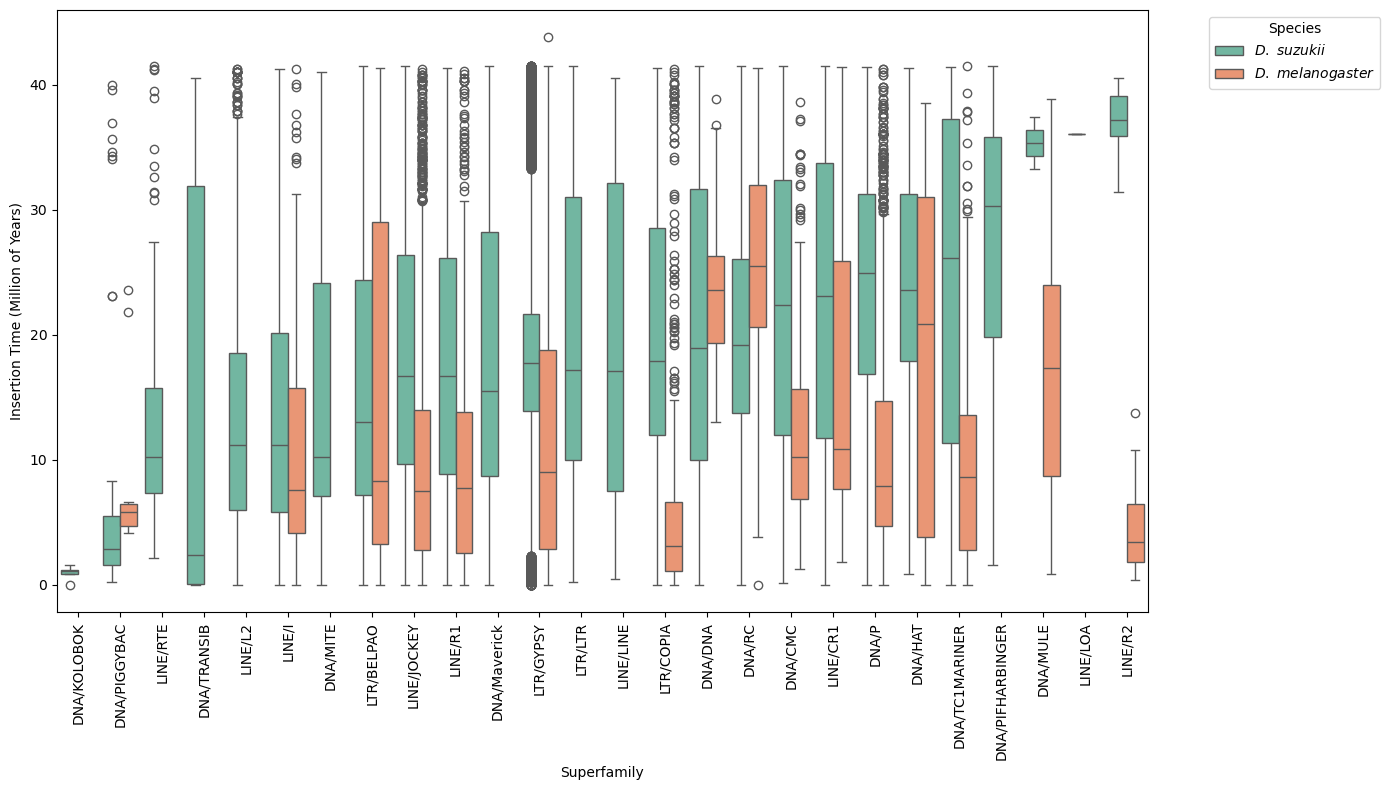

In [41]:
plot_insertion_time_by_class_one_plot(df_it_suz, df_it_melanogaster, 'Insertion time by superfamily: D. suzukii vs D. melanogaster', 'insertion_time_comparison_one_plot.png')

In [42]:
def plot_te_distribution_heatmap_one_plot(ocfta_df_suzukii, ocfta_df_melanogaster, genome_file_suzukii, genome_file_melanogaster, plot_title, image_path):
    """
    Grafica la densidad de TEs en los cromosomas principales de los genomas de Drosophila suzukii y Drosophila melanogaster
    utilizando heatmaps y muestra ambos gráficos en la misma figura, sin cuadrícula de fondo.
    También añade marcas individuales para indicar los finales de cada cromosoma.

    Parámetros:
    ocfta_df_suzukii (pd.DataFrame): DataFrame con los datos de OCFTA para D. suzukii.
    ocfta_df_melanogaster (pd.DataFrame): DataFrame con los datos de OCFTA para D. melanogaster.
    genome_file_suzukii (str): Ruta al archivo FASTA del genoma de D. suzukii.
    genome_file_melanogaster (str): Ruta al archivo FASTA del genoma de D. melanogaster.
    plot_title (str): Título general de la figura.
    image_path (str): Ruta donde se guardará la imagen.

    Retorna:
    None
    """

    # Definir el tamaño de los bins para la agrupación
    bin_size = 1000000  # 1 Mb

    # Función auxiliar para procesar cada DataFrame
    def process_te_data(ocfta_df, genome_file):
        main_chromosomes = get_main_chromosomes(genome_file)
        ocfta_df['Alignment_Start'] = ocfta_df['Alignment_Start'].astype(int)
        ocfta_df['Alignment_End'] = ocfta_df['Alignment_End'].astype(int)
        ocfta_df['bin'] = ocfta_df['Alignment_Start'] // bin_size
        grouped = ocfta_df.groupby(['Sequence_Name', 'bin']).size().reset_index(name='te_count')
        grouped['te_density'] = grouped['te_count'] / (bin_size / 1e6)
        grouped = grouped[grouped['Sequence_Name'].isin(main_chromosomes)]
        grouped['Sequence_Name'] = grouped['Sequence_Name'].apply(lambda x: get_chromosome_name(x, genome_file))
        heatmap_data = grouped.pivot(index='Sequence_Name', columns='bin', values='te_density').fillna(0)
        return heatmap_data, grouped

    # Procesar los datos de ambas especies
    heatmap_data_suzukii, grouped_suzukii = process_te_data(ocfta_df_suzukii, genome_file_suzukii)
    heatmap_data_melanogaster, grouped_melanogaster = process_te_data(ocfta_df_melanogaster, genome_file_melanogaster)

    # Configuración del tamaño de la figura y estilo sin cuadrícula
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(36, 12), sharey=False)
    sns.set(style="white")  # Estilo sin cuadrícula

    # Función para calcular las posiciones finales de los cromosomas
    def calculate_chromosome_end_positions(grouped_df, heatmap_data):
        chrom_positions = {}
        for chrom in heatmap_data.index:
            max_bin = grouped_df[grouped_df['Sequence_Name'] == chrom]['bin'].max()
            chrom_positions[chrom] = max_bin + 1  # +1 para incluir el último bin
        return chrom_positions

    # Calcular los finales de los cromosomas
    chrom_ends_suzukii = calculate_chromosome_end_positions(grouped_suzukii, heatmap_data_suzukii)
    chrom_ends_melanogaster = calculate_chromosome_end_positions(grouped_melanogaster, heatmap_data_melanogaster)

    # Heatmap para D. suzukii
    sns.heatmap(heatmap_data_suzukii, ax=ax1, cmap="viridis", cbar_kws={'label': 'TE Density (per Mb)'}, linewidths=0, vmin=0, vmax=1000)
    ax1.set_title("D. suzukii", fontsize=14, fontweight='bold', pad=10, loc='center', fontstyle='italic')
    ax1.set_xlabel('Position in the chromosome (Mb)')
    ax1.set_ylabel('Chromosomes')
    ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax1.set_yticks(np.arange(len(heatmap_data_suzukii.index)))
    fig.canvas.draw()

    plt.setp(ax1.get_yticklabels(), fontsize=16)
    plt.setp(ax1.get_xticklabels(), fontsize=14)

    # Añadir marcas individuales para los finales de los cromosomas para D. suzukii
    for chrom, end in chrom_ends_suzukii.items():
        y_start = heatmap_data_suzukii.index.get_loc(chrom)
        y_end = y_start + 1
        ax1.vlines(x=end, ymin=y_start, ymax=y_end, color='red', linestyle='-', linewidth=2.5)

    # Heatmap para D. melanogaster
    sns.heatmap(heatmap_data_melanogaster, ax=ax2, cmap="viridis", cbar_kws={'label': 'TE Density (per Mb)'}, linewidths=0, vmin=0, vmax=1000)
    ax2.set_title("D. melanogaster", fontsize=25, fontweight='bold', pad=10, loc='center', fontstyle='italic')
    ax2.set_xlabel('Position in the chromosome (Mb)')
    ax2.set_ylabel('Chromosomes')
    ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, fontsize=25, fontweight='bold', va='top', ha='right')
    ax2.set_yticks(np.arange(len(heatmap_data_melanogaster.index)))
    ax2.set_yticklabels(heatmap_data_melanogaster.index, fontsize=16)

    ax1.set_yticks(np.arange(len(heatmap_data_suzukii.index)))
    ax1.set_yticklabels(list(heatmap_data_suzukii.index), fontsize=22)

    ax2.set_yticks(np.arange(len(heatmap_data_melanogaster.index)))
    ax2.set_yticklabels(list(heatmap_data_melanogaster.index), fontsize=16)

    # Añadir marcas individuales para los finales de los cromosomas para D. melanogaster
    for chrom, end in chrom_ends_melanogaster.items():
        y_start = heatmap_data_melanogaster.index.get_loc(chrom)
        y_end = y_start + 1
        ax2.vlines(x=end, ymin=y_start, ymax=y_end, color='red', linestyle='-', linewidth=2.5)

    # Título general y ajuste final
    #plt.suptitle(plot_title, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Guardar la gráfica sin recortes
    plt.savefig(image_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()

--- Procesando D. suzukii ---
probando:  NC_092080.1
probando:  NC_092081.1
probando:  NC_092082.1
probando:  NC_092083.1
probando:  NC_092084.1
probando:  NC_092085.1
--- Procesando D. melanogaster ---
probando:  NC_004354.4
probando:  NT_033779.5
probando:  NT_033778.4
probando:  NT_037436.4
probando:  NT_033777.3
probando:  NC_004353.4
probando:  NC_024512.1
Escala de color ajustada: vmin=0, vmax=726.45 (basado en percentil 95)


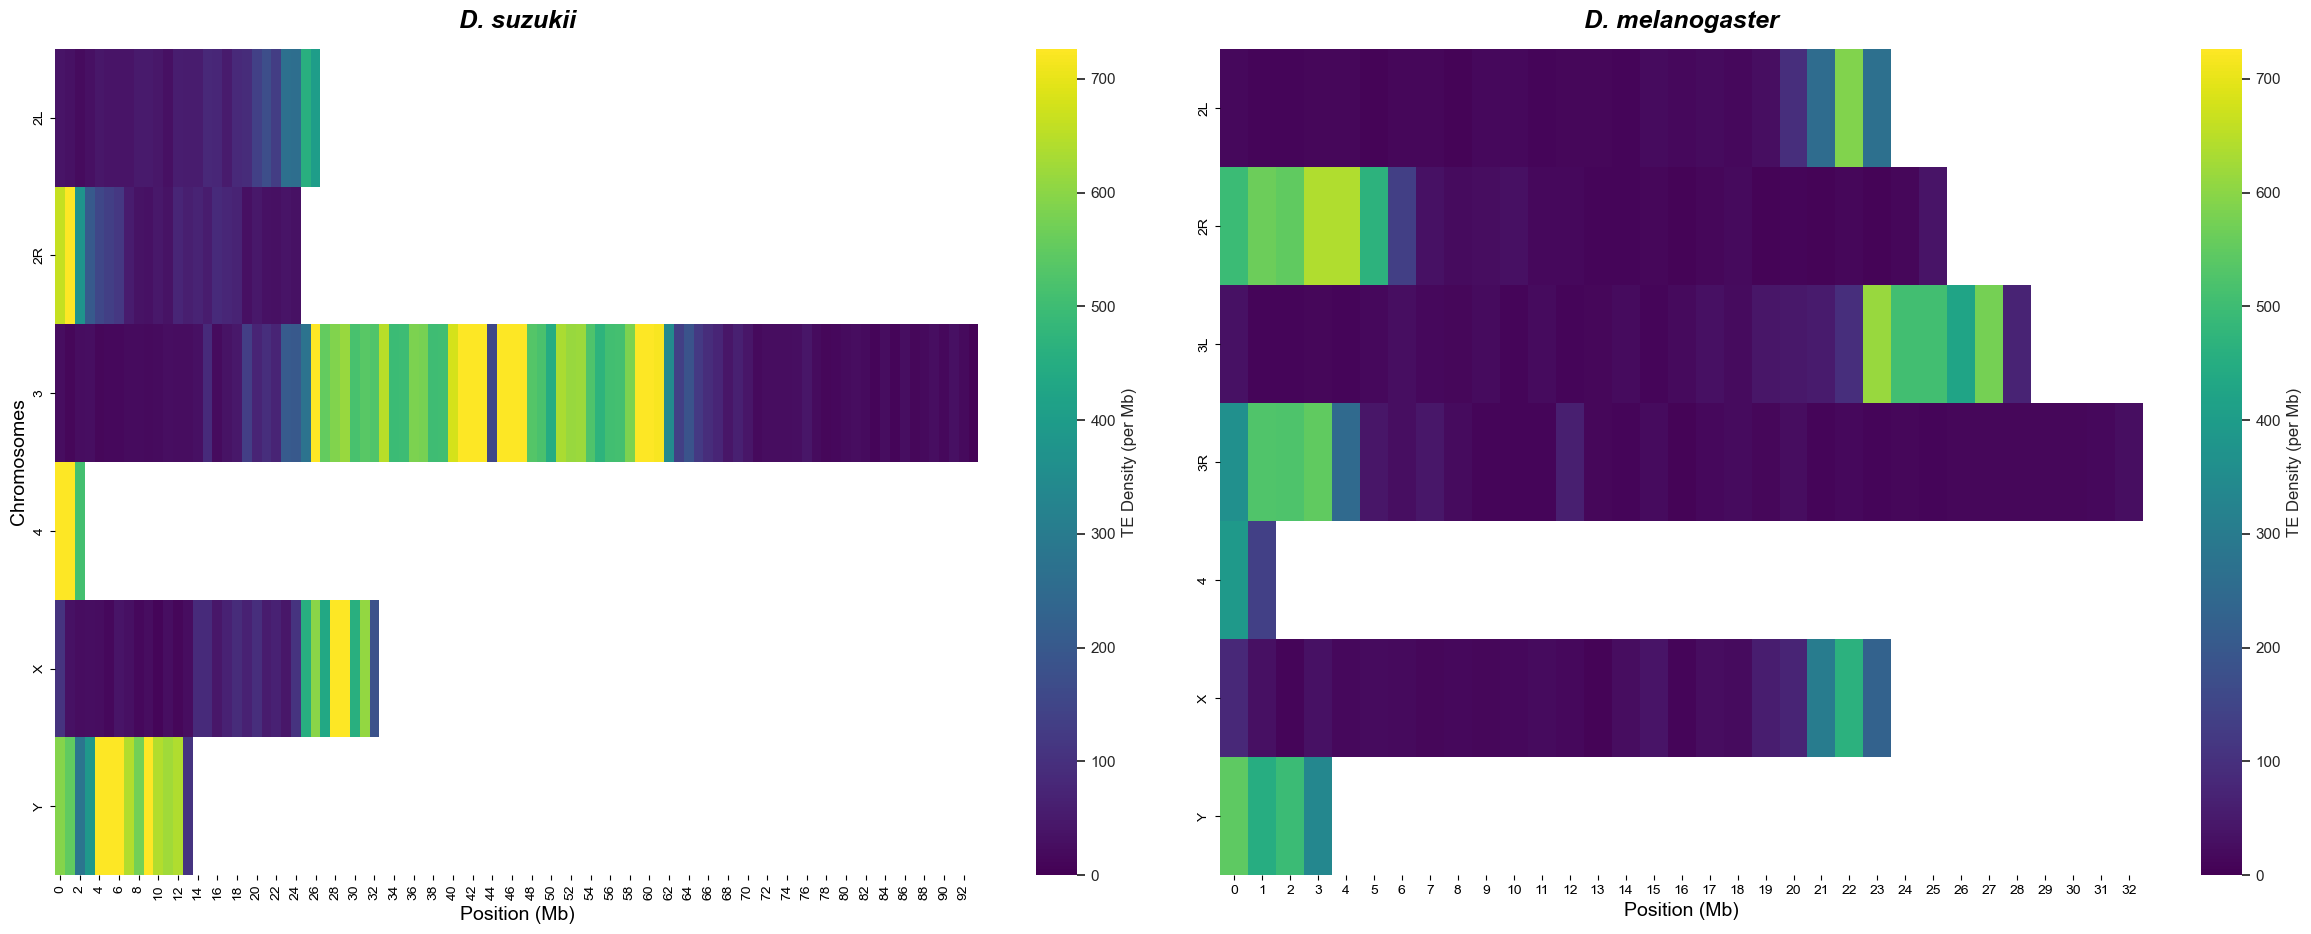

In [43]:
plot_te_distribution_heatmap_corrected(te_annotation_df_suzukii, te_annotation_df_melano, 'D_suzukii_GCF_043229965.1.fna', 'D_melanogaster_GCF_000001215.4.fna', "Heatmap of TE Density in Chromosomes D. suzukii and D. melanogaster", "density_by_chromosome_both_species_one_plot.png")

In [44]:
def generate_histogram_by_class_one_plot(df_suzukii, df_melanogaster, plot_title, image_path):
    """
    Genera una imagen con dos subplots de histogramas de divergencia por clase para D. suzukii y D. melanogaster.
    Cada subplot representa la frecuencia de divergencia para cada clase de elementos transponibles, con escalas independientes en el eje y.

    Parámetros:
    - df_suzukii: DataFrame con la anotación de elementos transponibles para D. suzukii.
    - df_melanogaster: DataFrame con la anotación de elementos transponibles para D. melanogaster.
    - plot_title: Título general de la gráfica.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra y guarda una imagen con dos subplots de histogramas.
    """

    # Configuración del tamaño de la figura y estilo sin cuadrícula
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    sns.set(style="white")  # Estilo sin cuadrícula

    # Obtener las clases únicas de cada DataFrame
    classes_suzukii = df_suzukii['Class'].unique()
    classes_melanogaster = df_melanogaster['Class'].unique()

    # Paleta de colores
    palette_suzukii = sns.color_palette("Set2", len(classes_suzukii))
    palette_melanogaster = sns.color_palette("Set2", len(classes_melanogaster))

    # Histograma para D. suzukii
    for i, cls in enumerate(classes_suzukii):
        subset = df_suzukii[df_suzukii['Class'] == cls]
        ax1.hist(subset['Divergence'], bins=30, alpha=0.6, label=cls, color=palette_suzukii[i])
    ax1.set_title("D. suzukii", fontsize=14, fontweight='bold')
    ax1.set_xlabel('Divergence (%)')
    ax1.set_ylabel('Frequency')
    ax1.legend(title='Superfamily', loc='upper right', fontsize=10)
    ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, fontsize=30, fontweight='bold', ha='center')
    ax1.grid(False)

    # Histograma para D. melanogaster
    for i, cls in enumerate(classes_melanogaster):
        subset = df_melanogaster[df_melanogaster['Class'] == cls]
        ax2.hist(subset['Divergence'], bins=30, alpha=0.6, label=cls, color=palette_melanogaster[i])
    ax2.set_title("D. melanogaster", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Divergence (%)')
    ax2.legend(title='Superfamily', loc='upper right', fontsize=10)
    ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, fontsize=30, fontweight='bold', ha='center')
    ax2.grid(False)

    # Título general y ajuste final
    plt.suptitle("", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Guardar la imagen sin recortes
    plt.savefig(image_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

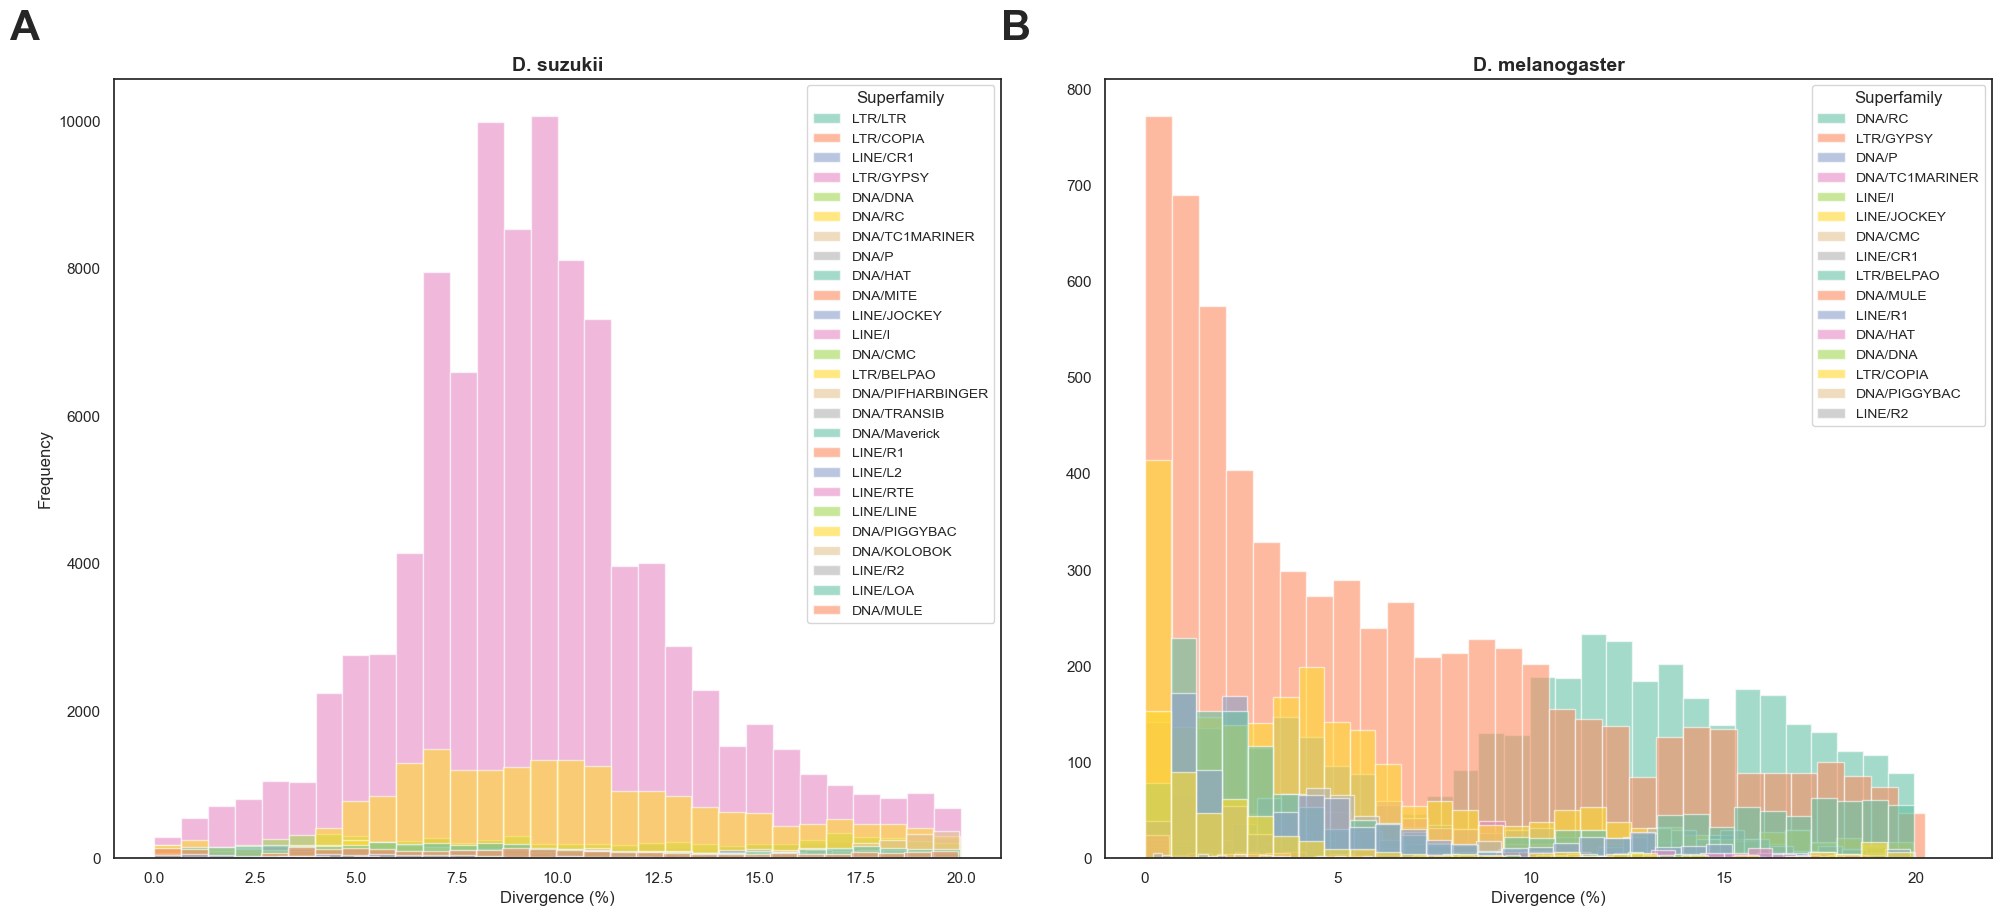

In [45]:
generate_histogram_by_class_one_plot(te_annotation_df_suzukii, te_annotation_df_melano, "Divergence by superfamily D. suzukii vs D. melanogaster", "divergence_by_class_comparison_one_plot.pdf")

In [47]:
def generate_histogram_by_order_from_class(df_suzukii, df_melanogaster, plot_title, image_path):
    """
    Genera una imagen con dos subplots de histogramas de divergencia por orden para D. suzukii y D. melanogaster,
    asegurando que los números en los ejes sean claros y bien distribuidos.

    Parámetros:
    - df_suzukii: DataFrame con la anotación de elementos transponibles para D. suzukii.
    - df_melanogaster: DataFrame con la anotación de elementos transponibles para D. melanogaster.
    - plot_title: Título general de la gráfica.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra y guarda una imagen con dos subplots de histogramas.
    """
    # Función para extraer el orden a partir del campo Class
    def extract_order(class_name):
        if "LTR" in class_name:
            return "LTR"
        elif "LINE" in class_name:
            return "LINE"
        elif "DNA" in class_name:
            return "DNA"
        else:
            return "Other"

    # Crear una nueva columna 'Order' basada en 'Class'
    df_suzukii['Order'] = df_suzukii['Class'].apply(extract_order)
    df_melanogaster['Order'] = df_melanogaster['Class'].apply(extract_order)

    # Configuración del tamaño de la figura y estilo sin cuadrícula
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
    sns.set(style="white")  # Estilo sin cuadrícula

    # Obtener los órdenes únicos de cada DataFrame
    orders_suzukii = df_suzukii['Order'].unique()
    orders_melanogaster = df_melanogaster['Order'].unique()

    # Paleta de colores
    palette_suzukii = sns.color_palette("Set2", len(orders_suzukii))
    palette_melanogaster = sns.color_palette("Set2", len(orders_melanogaster))

    # Crear histogramas y capturar frecuencias para determinar la escala máxima
    freq_suzukii = []
    for i, order in enumerate(orders_suzukii):
        subset = df_suzukii[df_suzukii['Order'] == order]
        hist, bins_suzukii = np.histogram(subset['Divergence'], bins=30)
        freq_suzukii.append(hist.max())
        ax1.hist(subset['Divergence'], bins=30, alpha=0.6, label=order, color=palette_suzukii[i])

    freq_melanogaster = []
    for i, order in enumerate(orders_melanogaster):
        subset = df_melanogaster[df_melanogaster['Order'] == order]
        hist, bins_melanogaster = np.histogram(subset['Divergence'], bins=30)
        freq_melanogaster.append(hist.max())
        ax2.hist(subset['Divergence'], bins=30, alpha=0.6, label=order, color=palette_melanogaster[i])

    # Calcular el rango máximo para el eje Y y añadir un margen
    max_y = max(max(freq_suzukii), max(freq_melanogaster))
    y_margin = max_y * 0.1  # Agregar un 10% de margen
    adjusted_max_y = max_y + y_margin

    # Configurar el rango del eje Y para ambos subplots
    ax1.set_ylim(0, adjusted_max_y)
    ax2.set_ylim(0, adjusted_max_y)

    # Mostrar etiquetas del eje Y en ambos subplots
    ax2.yaxis.set_tick_params(labelleft=True)

    # Ajustar los ticks del eje X y Y para mayor claridad
    ax1.set_xticks(bins_suzukii[::5])
    ax1.set_xticklabels([f"{int(x)}" for x in bins_suzukii[::5]], fontsize=14, rotation=0)
    ax2.set_xticks(bins_melanogaster[::5])
    ax2.set_xticklabels([f"{int(x)}" for x in bins_melanogaster[::5]], fontsize=14, rotation=0)

    ax1.set_yticks(ax1.get_yticks())
    ax1.set_yticklabels([f"{int(y)}" for y in ax1.get_yticks()], fontsize=14)
    ax2.set_yticks(ax2.get_yticks())
    ax2.set_yticklabels([f"{int(y)}" for y in ax2.get_yticks()], fontsize=14)

    # Ajustar títulos, etiquetas y leyendas
    ax1.set_title("D. suzukii", fontsize=25, fontweight='bold', fontstyle='italic')
    ax1.set_xlabel('Divergence (%)', fontsize=20)
    ax1.set_ylabel('Frequency', fontsize=20)  # Etiqueta del eje Y para el primer subplot
    ax1.legend(title='Order', loc='upper right', fontsize=15)
    ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, fontsize=40, fontweight='bold', ha='center')
    ax1.grid(False)

    ax2.set_title("D. melanogaster", fontsize=25, fontweight='bold', fontstyle='italic')
    ax2.set_xlabel('Divergence (%)', fontsize=20)
    ax2.set_ylabel('Frequency', fontsize=20)  # Etiqueta del eje Y para el segundo subplot
    ax2.legend(title='Order', loc='upper right', fontsize=15)
    ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, fontsize=40, fontweight='bold', ha='center')
    ax2.grid(False)

    # Título general y ajuste final
    #plt.suptitle(plot_title, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Guardar la imagen sin recortes
    plt.savefig(image_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()


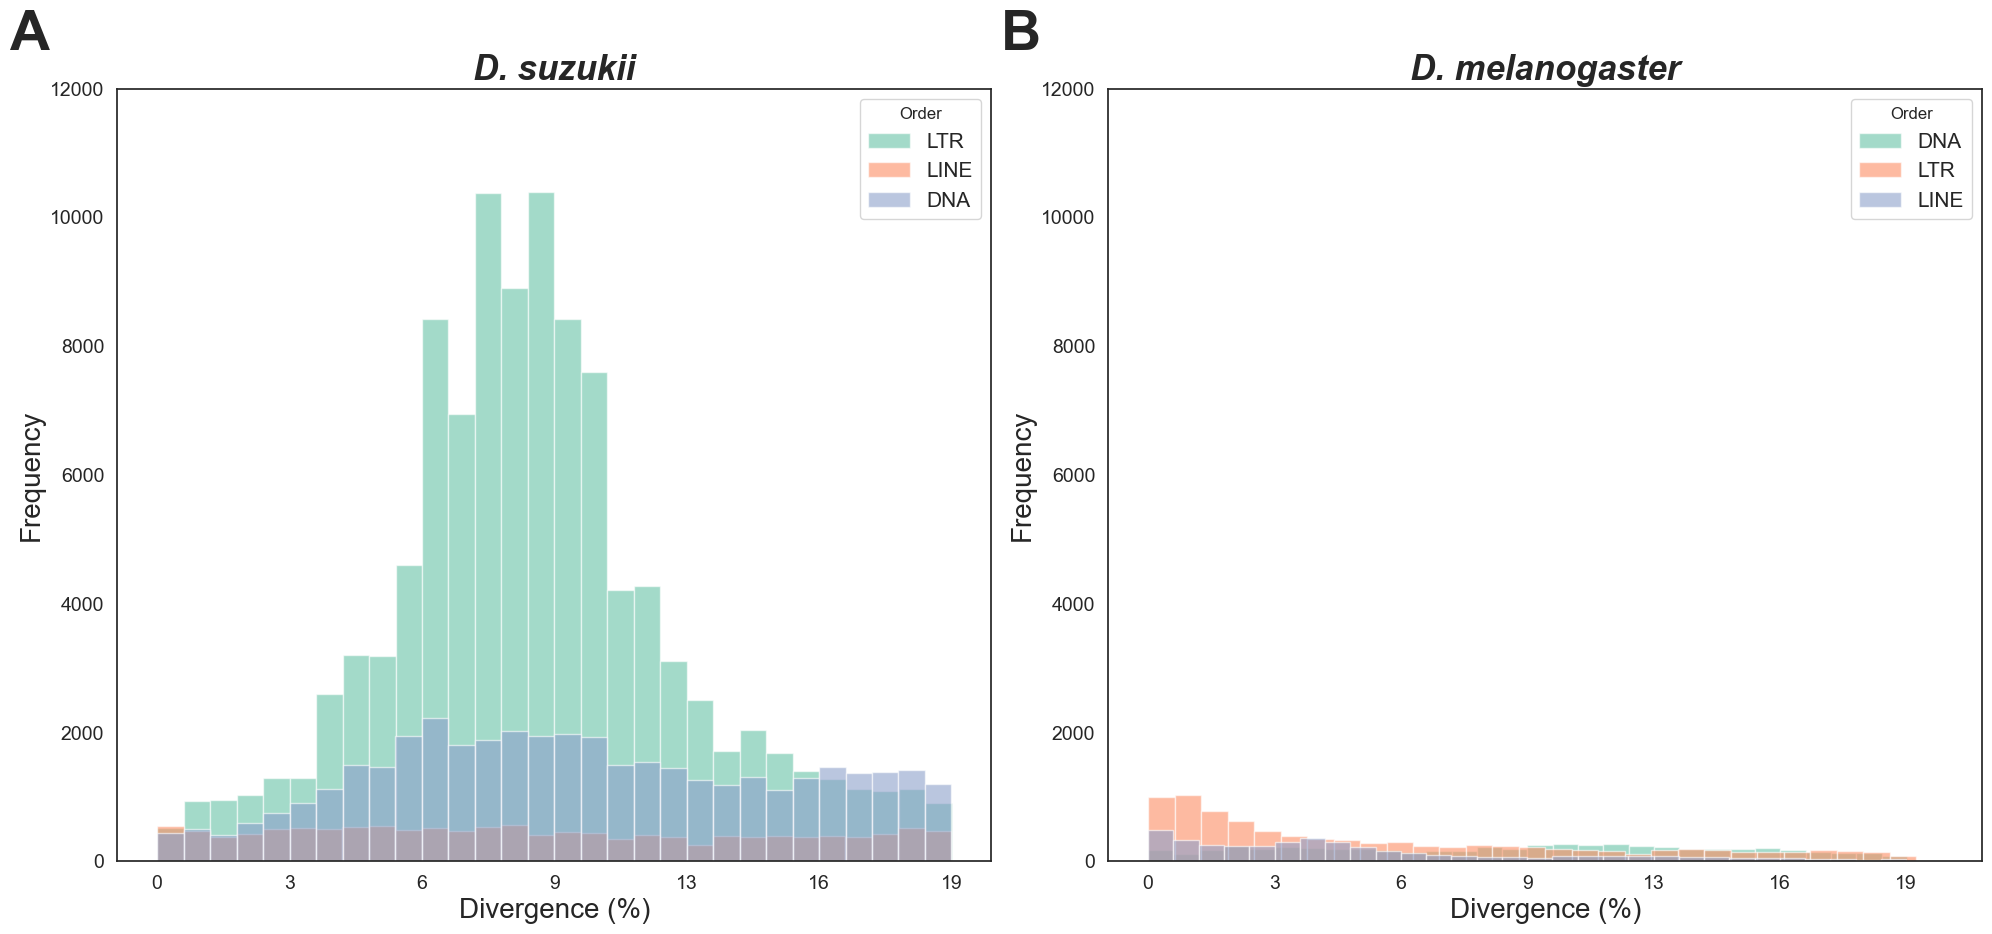

In [48]:
generate_histogram_by_order_from_class(te_annotation_df_suzukii, te_annotation_df_melano, "Divergence by order D. suzukii vs D. melanogaster", "divergence_by_class_comparison_one_plot.pdf")

In [34]:
def generate_histograms_by_superfamily_sub_plots(df_suzukii, df_melanogaster, plot_title, image_path):
    """
    Genera una imagen con subplots de histogramas de divergencia por superfamilia para D. suzukii y D. melanogaster,
    asegurando que los números en los ejes sean claros y bien distribuidos, y utilizando el mismo código de color que en plot_insertion_time_by_class_one_plot.

    Parámetros:
    - df_suzukii: DataFrame con la anotación de elementos transponibles para D. suzukii.
    - df_melanogaster: DataFrame con la anotación de elementos transponibles para D. melanogaster.
    - plot_title: Título general de la gráfica.
    - image_path: Ruta para guardar la imagen generada.

    Retorna:
    - None. Muestra y guarda una imagen con subplots de histogramas.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Obtener las superfamilias únicas de ambos DataFrames
    superfamilias_suzukii = df_suzukii['Class'].unique()
    superfamilias_melanogaster = df_melanogaster['Class'].unique()
    superfamilias = np.unique(np.concatenate((superfamilias_suzukii, superfamilias_melanogaster)))

    n_superfamilias = len(superfamilias)
    n_cols = 4  # Ahora habrá 4 gráficos por fila
    n_rows = int(np.ceil(n_superfamilias / n_cols))

    # Configuración del tamaño de la figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
    sns.set(style="white")  # Estilo sin cuadrícula

    axes = axes.flatten()

    # Definir la paleta de colores consistente con plot_insertion_time_by_class_one_plot
    palette = ["#66c2a5", "#fc8d62"]  # Colores para D. suzukii y D. melanogaster respectivamente

    for i, superfamilia in enumerate(superfamilias):
        ax = axes[i]

        # Subset de los DataFrames para la superfamilia actual
        subset_suzukii = df_suzukii[df_suzukii['Class'] == superfamilia]
        subset_melanogaster = df_melanogaster[df_melanogaster['Class'] == superfamilia]

        # Comprobar si hay datos para esta superfamilia en al menos una especie
        if subset_suzukii.empty and subset_melanogaster.empty:
            ax.axis('off')  # Ocultar subplot vacío
            continue

        # Obtener los datos de divergencia
        divergence_suzukii = subset_suzukii['Divergence']
        divergence_melanogaster = subset_melanogaster['Divergence']

        # Definir los bins de manera consistente entre especies
        min_divergence = min(divergence_suzukii.min() if not divergence_suzukii.empty else np.inf,
                             divergence_melanogaster.min() if not divergence_melanogaster.empty else np.inf)
        max_divergence = max(divergence_suzukii.max() if not divergence_suzukii.empty else -np.inf,
                             divergence_melanogaster.max() if not divergence_melanogaster.empty else -np.inf)
        bins = np.linspace(min_divergence, max_divergence, 30)

        # Plotear histogramas
        if not divergence_suzukii.empty:
            ax.hist(divergence_suzukii, bins=bins, alpha=0.6, label='D. suzukii', color=palette[0])
        if not divergence_melanogaster.empty:
            ax.hist(divergence_melanogaster, bins=bins, alpha=0.6, label='D. melanogaster', color=palette[1])

        # Etiquetas y título
        ax.set_xlabel('Divergence (%)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(superfamilia, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(False)

        # Ajustar los ticks del eje X e Y de forma independiente
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        ax.tick_params(axis='both', which='major', labelsize=8)

    # Eliminar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Ajustar el espacio entre subplots y el título principal
    plt.subplots_adjust(top=0.92, hspace=0.5)
    plt.suptitle(plot_title, fontsize=18, fontweight='bold')

    # Guardar la imagen
    plt.savefig(image_path, format='pnd', dpi=300, bbox_inches='tight')
    plt.show()


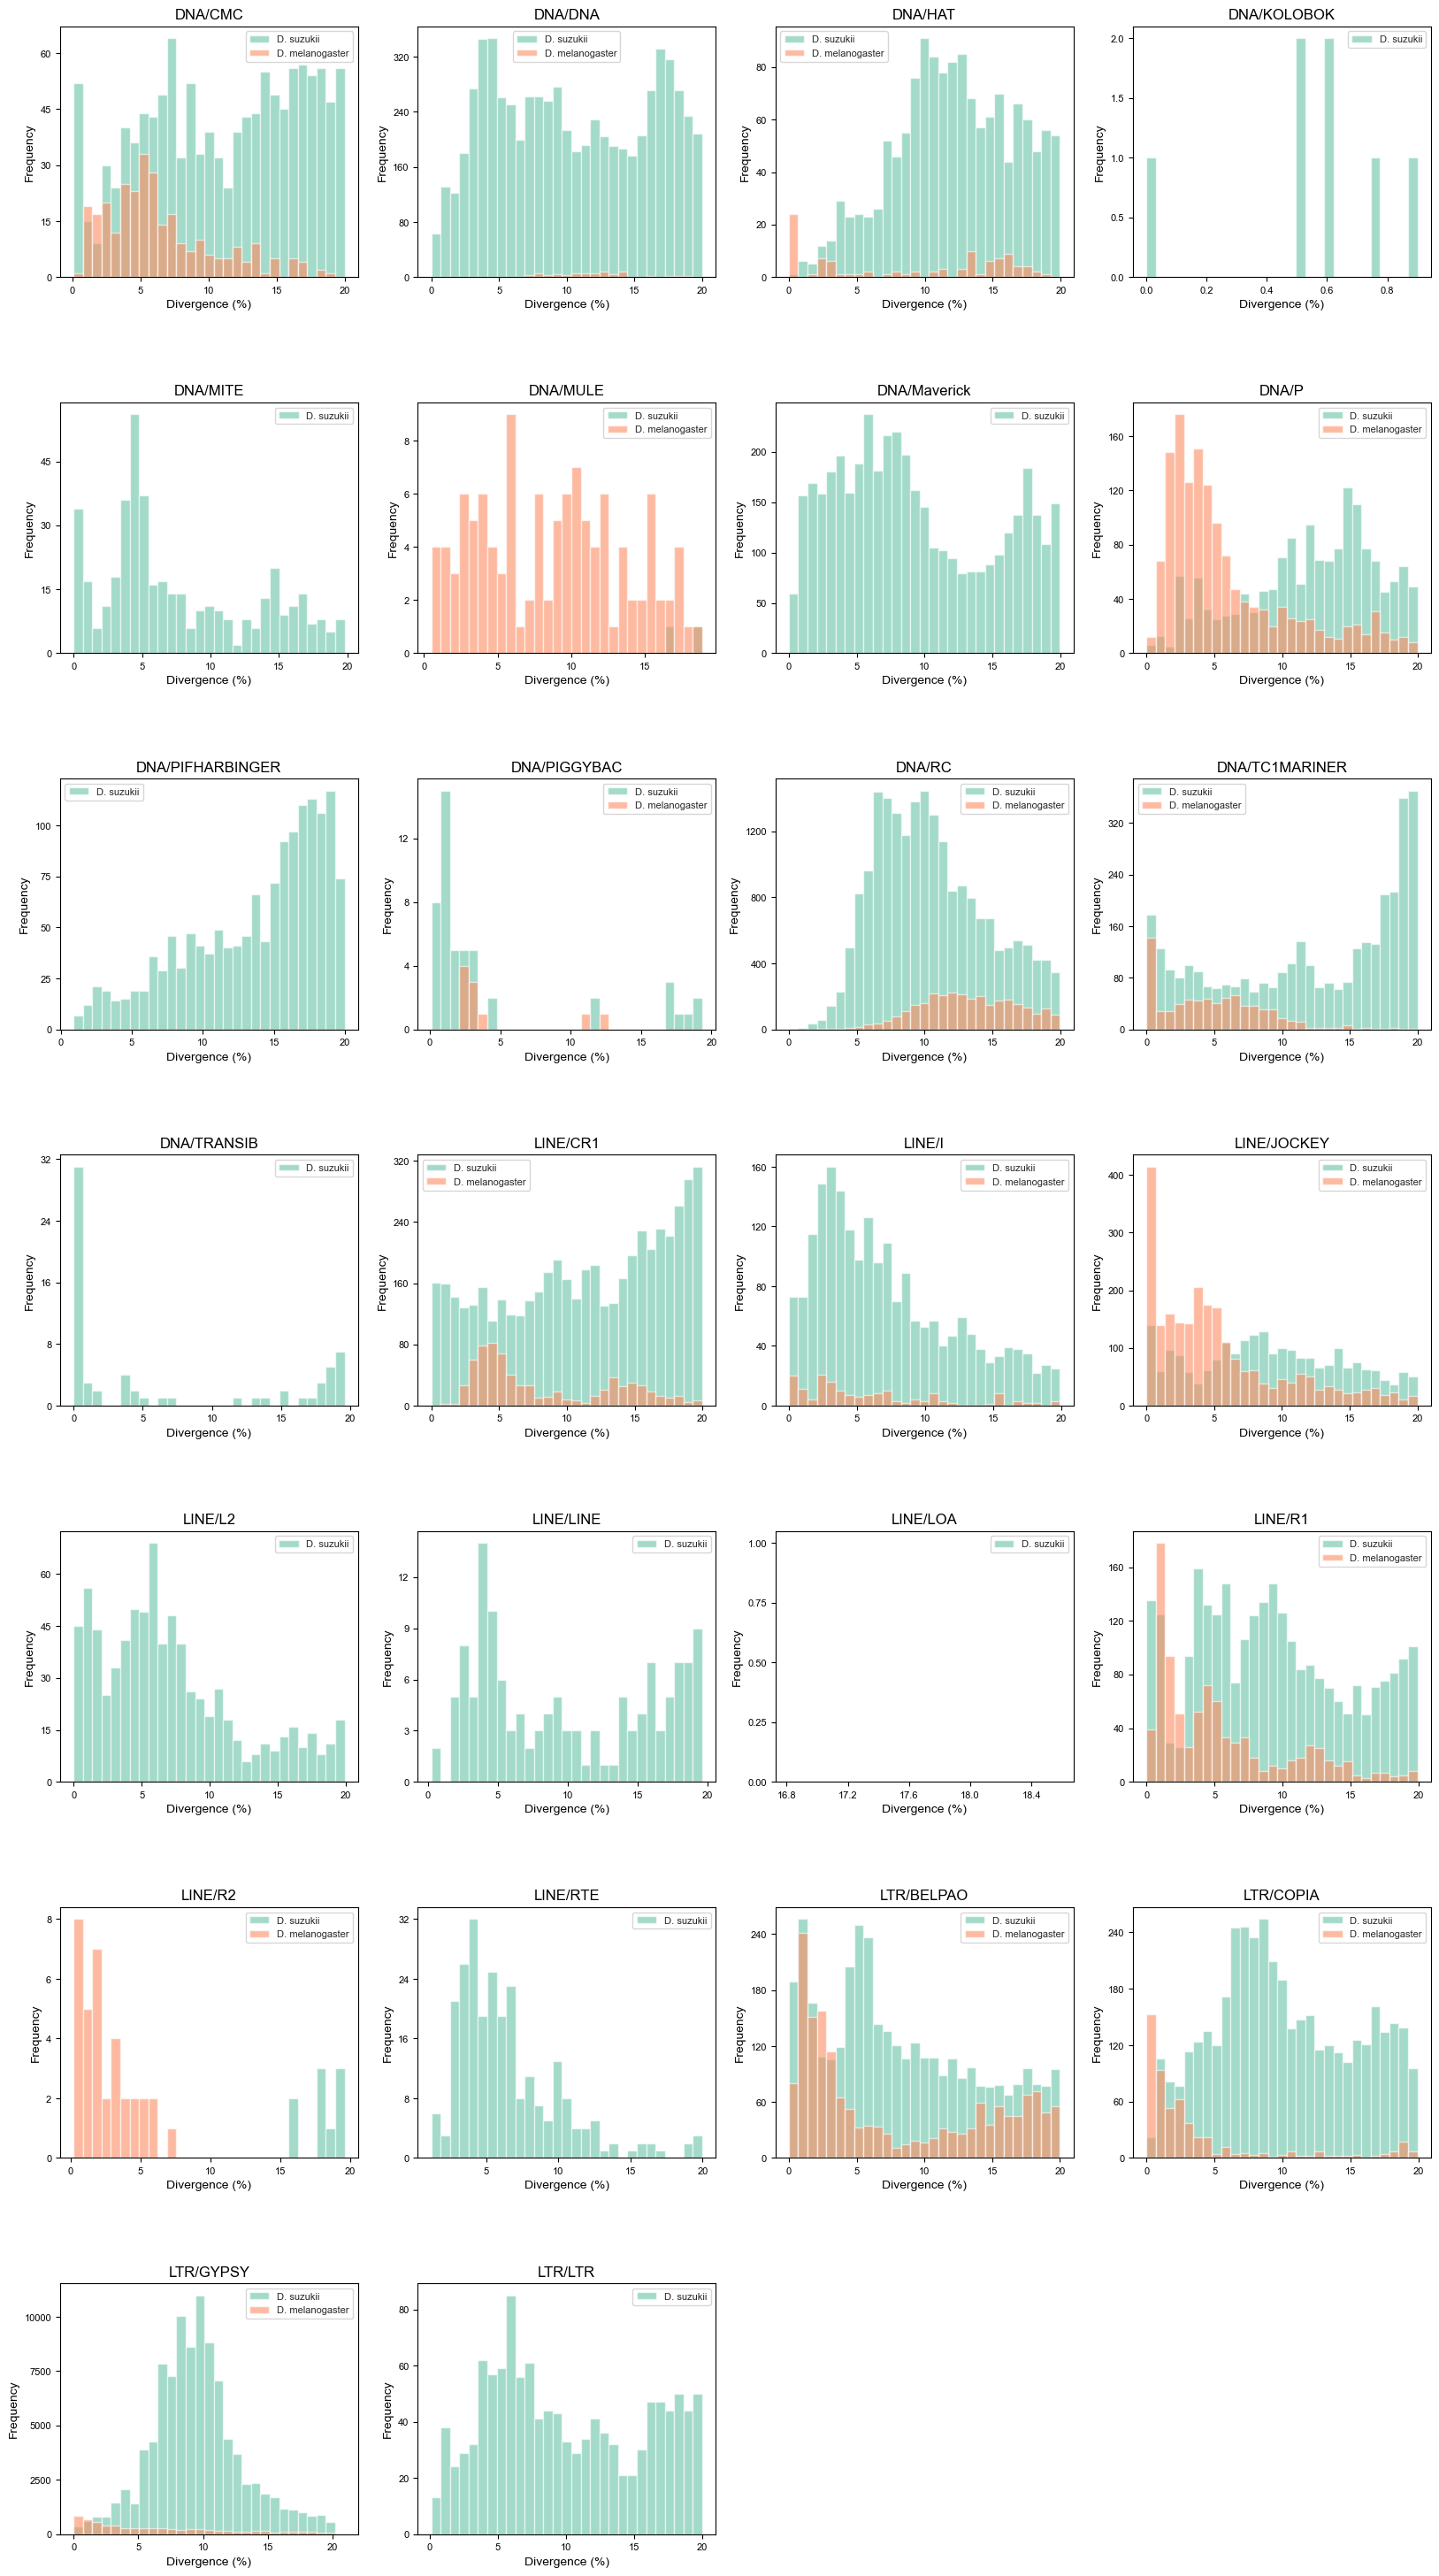

In [35]:
generate_histograms_by_superfamily_sub_plots(te_annotation_df_suzukii, te_annotation_df_melano, "", "divergence_by_superfamily_subplots.pdf")